<!-- !pip install rouge-score -->
<!-- pip install nltk rouge-score sentence-transformers bert-score -->


## TOOLS TO INSTALL

For Language Detection:

pip install "lingua-language-detector>=2.0.0" regex

(optional) for speedups on some platforms:
pip install orjson

In [1]:
# SETUP FOR LANGUAGE DETECTION
from lingua import Language, LanguageDetectorBuilder

TARGET_LANGS = [
    Language.ENGLISH,
    Language.CHINESE,   # Lingua reports CHINESE (no “zh-CN” vs “zh-TW” split)
    Language.GERMAN,
    Language.BULGARIAN,
    Language.FRENCH,
]

# Preload models to avoid lazy-loading overhead during the run
detector = (LanguageDetectorBuilder
            .from_languages(*TARGET_LANGS)
            .with_preloaded_language_models()
            .build())

def lingua_detect(text: str):
    lang = detector.detect_language_of(text)            # returns a Language enum or None
    if lang is None:
        return {"lang": None, "confidence": 0.0}

    # Per-language confidence (0..1). Deterministic across runs.
    conf = detector.compute_language_confidence(text, lang)
    # ISO-ish mapping you can store in your data
    lang_map = {
        Language.ENGLISH: "en",
        Language.CHINESE: "zh",
        Language.GERMAN: "de",
        Language.BULGARIAN: "bg",
        Language.FRENCH: "fr",
    }
    return {"lang": lang_map.get(lang), "confidence": conf}

## Reformat Label Studio Export Json

In [2]:
# CONFIG
from pathlib import Path


LABEL_STUDIO_EXPORT_DIR_NAME = "project_exports"
REFORMATTED_DATASET_OUTPUT_DIR = "dataset_formatted"

# LABEL_STUDIO_EXPORT_FILENAME = "project-1-at-2025-08-18-16-58-9aae2ecb.json"
LABEL_STUDIO_EXPORT_FILENAME = None
# REFORMATTED_PROJECT_OUTPUT_JSON_PATH = f"{REFORMATTED_DATASET_OUTPUT_DIR}/reformatted_label_data_{Path(LABEL_STUDIO_EXPORT_FILENAME).stem}.json"     # not merged
REFORMATTED_PROJECT_OUTPUT_JSON_PATH = None


MERGED_DATASET_FILENAME = "dataset_task-grouped.json"
MERGED_ANNOTATION_INDIVIDUALIZED_DATASET_FILENAME = "dataset_annotation_individualized.json"

MERGED_OUTPUT_JSON_PATH = f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_DATASET_FILENAME}"

ERROR_ANALYSIS_EVAL_DIR = "auto_error_analysis_evaluation"
ANNOTATION_SEPARATED_DATASET_SAMPLE_FOR_TESTS_FILENAME = "sampled_annotations.json"


In [3]:
# HELPERS

import re
import json

def wrap_entries_for_label_studio(input_path, output_path):
    """
    Wraps each entry in the dataset in a top-level {"data": ...} structure
    for import into Label Studio.
    """
    with open(input_path, "r", encoding="utf-8") as f:
        entries = json.load(f)

    wrapped_entries = [{"data": entry} for entry in entries]

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(wrapped_entries, f, indent=2, ensure_ascii=False)

    print(f"✅ Label Studio-ready dataset saved to: {output_path}")


## Version 1: Adds unnecessary extra \
def clean_latex_backslashes(text: str) -> str:
    """
    Fix LaTeX-style backslashes that have been double-escaped or misinterpreted.
    Ensures consistent escaping for JSON export.
    """
    if not isinstance(text, str):
        return text

    # Common invalid escape sequences (e.g. \t, \f) that should be preserved
    # Replace them with double backslashes if they appear as raw escape sequences
    text = re.sub(r'\\(?![\\{}$])', r'\\\\', text)

    # Optional: ensure all single backslashes are doubled
    # (If you're unsure what came from original LaTeX vs user entry)
    # text = text.replace('\\', '\\\\')

    return text


def normalize_latex_backslashes(text: str) -> str:
    """
    Clean LaTeX-style text to ensure single backslashes are used correctly.
    Removes extra backslashes from patterns like \\tlog or \\fcolor, while preserving valid LaTeX.
    """
    if not isinstance(text, str):
        return text

    # Replace double backslashes before LaTeX-like commands (e.g., \\tlog → \tlog)
    text = re.sub(r'\\\\([a-zA-Z]+)', r'\\\1', text)

    # Replace triple backslashes (extreme cases)
    text = re.sub(r'\\\\\\', r'\\', text)

    # (Optional) Handle overly escaped curly braces if present
    text = text.replace('\\{', '{').replace('\\}', '}')

    # Remove over-escaped parentheses (even 2+ backslashes)
    text = re.sub(r'\\+\(', '(', re.sub(r'\\+\)', ')', text))

    return text

def strip_latex_formatting(text: str) -> str:
    """
    Removes LaTeX-style formatting from a string to produce plaintext.
    This includes math delimiters, commands, and environments like \textbf, $, \[ \], etc.
    """
    if not isinstance(text, str):
        return text

    # Remove inline math delimiters: $...$
    text = re.sub(r'\$(.*?)\$', r'\1', text)

    # Remove block math delimiters: \[...\] and \(...\)
    text = re.sub(r'\\\[(.*?)\\\]', r'\1', text, flags=re.DOTALL)
    text = re.sub(r'\\\((.*?)\\\)', r'\1', text, flags=re.DOTALL)

    # Remove LaTeX commands like \command{...} → just keep the {...}
    text = re.sub(r'\\[a-zA-Z]+\*?{([^{}]*)}', r'\1', text)

    # Remove any standalone commands like \alpha, \gg, etc.
    text = re.sub(r'\\[a-zA-Z]+', '', text)

    # Remove escaped brackets (optional, in case they were left behind)
    text = text.replace('\\{', '{').replace('\\}', '}')
    text = text.replace('\\(', '(').replace('\\)', ')')

    # Remove any lingering double backslashes or environments
    text = text.replace('\\\\', '')
    
    # Normalize extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def clean_text(text: str) -> str:
    return strip_latex_formatting(text)
    # text = clean_latex_backslashes(text)
    # text = normalize_latex_backslashes(text)
    

In [5]:
import json

def reformat_label_studio_export(
    input_json_path,
    output_json_path
):
    with open(input_json_path, 'r', encoding='utf-8') as f:
        tasks = json.load(f)

    reformatted_data = []

    for task in tasks:
        data = task.get("data", {})

        figure_entry = {
            "task_id": task.get("id"),
            # "annotation_task_id": task.get("id"),
            "arxiv_id": data.get("arxiv_id"),
            "paper_title": data.get("paper_title"),
            "paper_language": data.get("paper_language", "English"),        # defaults to English because field was not included when only English papers added
            "figure_filename": data.get("figure_filename", "Value Missing"),
            "figure_image": data.get("figure_image"),
            "caption": clean_text(data.get("caption", "Value Missing")),
            "gpt-labeled_plot_type": data.get("gpt-labeled_plot_type", "Value Missing"),
            "gpt_annotation": clean_text(data.get("gpt_annotation", "Value Missing")),
            "annotations": []
        }

        # Extract annotations if present
        if "annotations" in task:
            for annotation in task["annotations"]:
                completed_by = annotation.get("completed_by", "Value Missing")
                if isinstance(completed_by, dict):
                    completed_by_id = completed_by.get("id", "Value Missing")
                else:
                #   completed_by_id = "Value Missing"
                    completed_by_id = completed_by

                # Default values for each field
                figure_type = "Value Missing"
                annotation_language = "Value Missing"
                gpt_annotation_translation = "Value Missing"
                human_annotation = "Value Missing"

                # Process all results in this annotation
                for result in annotation.get("result", []):
                    from_name = result.get("from_name", "")
                    value = result.get("value", {})

                    if from_name == "figure/plot type" and "choices" in value:
                        figure_type = value["choices"][0]
                    elif from_name == "caption language" and "choices" in value:
                        annotation_language = value["choices"][0]
                    elif from_name == "generated_annotation_translated" and "text" in value:
                        gpt_annotation_translation = value["text"][0]
                    elif from_name == "human_annotation" and "text" in value:
                        human_annotation = value["text"][0]

                # Build annotation object
                annotation_entry = {
                    "annotation_id": annotation.get("id"),
                    "annotated_by": completed_by_id,
                    "figure_type": figure_type,
                    "annotation_language": annotation_language,
                    "gpt_annotation_translation": clean_text(gpt_annotation_translation),
                    "annotation": clean_text(human_annotation)
                }

                figure_entry["annotations"].append(annotation_entry)

        reformatted_data.append(figure_entry)

    # Write out the new JSON structure
    with open(output_json_path, 'w', encoding='utf-8') as f_out:
        json.dump(reformatted_data, f_out, indent=2, ensure_ascii=False)

    print(f"✅ Reformatted {len(reformatted_data)} figure tasks and saved to {output_json_path}")


In [6]:
def reformat_and_combine_all_label_studio_exports(
        label_studio_output_dir_path,
        merged_output_json_path):
    merged_data = []
    
    try:
        path = Path(label_studio_output_dir_path)
        for entry in path.iterdir():
            filename = entry.name
            if entry.is_file():
                output_file_path = f"{REFORMATTED_DATASET_OUTPUT_DIR}/reformatted_label_data_{Path(filename).stem}.json"
                reformat_label_studio_export(
                    input_json_path= f"{LABEL_STUDIO_EXPORT_DIR_NAME}/{filename}",
                    output_json_path=output_file_path
                )

                # Merge
                with open(output_file_path, 'r', encoding='utf-8') as infile:
                    try:
                        file_data = json.load(infile)
                        # Ensure that the loaded data is a list
                        if isinstance(file_data, list):
                            merged_data.extend(file_data)  # Add all objects from the current file's list
                        else:
                            print(f"Warning: File '{filename}' does not contain a list of JSON objects. Skipping.")
                    except json.JSONDecodeError:
                        print(f"Error: Could not decode JSON from file '{filename}'. Skipping.")
                    except Exception as e:
                        print(f"An unexpected error occurred while processing '{filename}': {e}")

        
        with open(merged_output_json_path, 'w', encoding='utf-8') as outfile:
            json.dump(merged_data, outfile, indent=2, ensure_ascii=False)  # Use indent for pretty printing
        print(f"\nSuccessfully merged JSON files into '{merged_output_json_path}'")

    except FileNotFoundError:
        print(f"Error: Directory '{label_studio_output_dir_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")


In [ ]:
reformat_label_studio_export(
    input_json_path= f"{LABEL_STUDIO_EXPORT_DIR_NAME}/{LABEL_STUDIO_EXPORT_FILENAME}",
    output_json_path=REFORMATTED_PROJECT_OUTPUT_JSON_PATH
)

In [92]:
reformat_and_combine_all_label_studio_exports(
    label_studio_output_dir_path = LABEL_STUDIO_EXPORT_DIR_NAME,
    merged_output_json_path= MERGED_OUTPUT_JSON_PATH
)

✅ Reformatted 203 figure tasks and saved to dataset_formatted/reformatted_label_data_project-BASE-at-2025-10-25-08-54-5e427740.json
✅ Reformatted 304 figure tasks and saved to dataset_formatted/reformatted_label_data_project-BULGARIAN-at-2025-10-28-13-43-7e250157.json
✅ Reformatted 159 figure tasks and saved to dataset_formatted/reformatted_label_data_project-CHINESE-at-2025-10-28-13-48-cd537f5b.json
✅ Reformatted 253 figure tasks and saved to dataset_formatted/reformatted_label_data_project-ENGLISH-at-2025-10-28-13-52-4f6e8cea.json
✅ Reformatted 86 figure tasks and saved to dataset_formatted/reformatted_label_data_project-GERMAN-at-2025-10-25-08-53-5a910edd.json

Successfully merged JSON files into 'dataset_formatted/dataset_task-grouped.json'


In [ ]:
# import json
# import random

# # Load tasks from the input JSON file
# with open("reformatted_label_data_full.json", "r", encoding="utf-8") as f:
#     tasks = json.load(f)

# # Calculate the number of tasks to select (25%)
# sample_size = max(1, len(tasks) // 4)
# sampled_tasks = random.sample(tasks, sample_size)

# # Save the sampled tasks to a new JSON file
# with open("sampled_tasks.json", "w", encoding="utf-8") as f:
#     json.dump(sampled_tasks, f, indent=2, ensure_ascii=False)

# print(f"Selected {sample_size} tasks and saved to 'sampled_tasks.json'")


#### Convert Dataset into Annotation-individualized Variant

In [17]:
def flatten_annotation_dataset(input_path, output_path):
    """
    Converts a dataset where each task contains multiple annotations
    into a flat list of annotation records, each with all task-level fields included.

    Args:
        input_path (str): Path to the original task-grouped JSON file.
        output_path (str): Path where the flattened JSON file will be saved.
    """
    # Load the original dataset
    with open(input_path, "r", encoding="utf-8") as f:
        task_grouped_data = json.load(f)

    # Flatten the dataset
    flattened_data = []
    for task in task_grouped_data:
        # Extract task-level fields (excluding the annotations list)
        base_task_info = {k: v for k, v in task.items() if k != "annotations"}
        for annotation in task.get("annotations", []):
            # Merge task-level and annotation-level fields
            combined_entry = {**base_task_info, **annotation}
            flattened_data.append(combined_entry)

    # Save the flattened dataset
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(flattened_data, f, indent=2, ensure_ascii=False)

    print(f"✅ Flattened dataset saved to: {output_path}")


In [94]:
flatten_annotation_dataset(
    input_path=MERGED_OUTPUT_JSON_PATH,
    output_path=f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_ANNOTATION_INDIVIDUALIZED_DATASET_FILENAME}"
)

✅ Flattened dataset saved to: dataset_formatted/dataset_annotation_individualized.json


## Analyse Annotations

In [18]:
# Use THIS if only reformatted single file

INPUT_JSON_PATH = f"{REFORMATTED_DATASET_OUTPUT_DIR}/{LABEL_STUDIO_EXPORT_FILENAME}"

In [20]:
# Use THIS if reformatted and merged multiple project exports

INPUT_JSON_PATH = f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_DATASET_FILENAME}"
INPUT_JSON_PATH

'dataset_formatted/dataset_task-grouped.json'

In [21]:
# UTILITY FOR LISTING OUT ANNOTATOR IDs

import json

with open(INPUT_JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

annotators = set()
for task in data:
    if "annotations" in task:
        for annotation in task["annotations"]:
            annotator_id = annotation.get("annotated_by", "Value Missing")
            # completed_by = annotation.get("completed_by")
            if isinstance(annotator_id, int) and annotator_id not in annotators:
                annotators.add(annotator_id)

print("Annotator IDs found:", annotators)
print("\nNote: Make sure all IDs listed above are mapped to an annotator")

Annotator IDs found: {1, 2, 3, 7, 8, 9, 10, 11}

Note: Make sure all IDs listed above are mapped to an annotator


In [22]:
# MAPPING ANNOTATOR IDs TO NAMES

ANNOTATOR_MAP = {
    1: "Owusu",
    2: "Doroteya",
    3: "Ying Xuan",
    7: "Jonas",
    8: "Ian",
    9: "Prasanna",
    10: "Goutham",
    11: "Pawan"
}

### Dataset Analysis

In [23]:
import json
import pandas as pd
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Data (USE THIS IF WORKING WITH LANGUAGE SPECIFIC LABELING PROJECT EXPORT)
with open(REFORMATTED_PROJECT_OUTPUT_JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

In [24]:
# Load Data (USE THIS IF WORKING WITH MERGED DATASET) ===
with open(MERGED_OUTPUT_JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

#### Dataset Summary Statistics

In [25]:
import pandas as pd
import json

def show_annotation_dataset_statistics():
    # Load dataset
    with open(f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_ANNOTATION_INDIVIDUALIZED_DATASET_FILENAME}", "r", encoding="utf-8") as f:
        data = json.load(f)

    df = pd.DataFrame(data)

    valid_types = ["Line Plot", "Bar Chart", "Pie Chart"]
    df = df[df["figure_type"].isin(valid_types)]

    # Pivot counts: paper_language × annotation_language × figure_type
    pivot = pd.pivot_table(
        df,
        index=["paper_language", "annotation_language"],
        columns="figure_type",
        aggfunc='size',
        fill_value=0
    )

    # Add total per language pair
    pivot["Total"] = pivot.sum(axis=1)

    # Optional: Add row total
    pivot.loc[("TOTAL", ""), :] = pivot.sum()

    # Convert to integers
    pivot = pivot.astype(int)

    display(pivot)
    

In [26]:
show_annotation_dataset_statistics()

figure_type                         Bar Chart  Line Plot  Pie Chart  Total
paper_language annotation_language                                        
Bulgarian      Bulgarian                  140        104         56    300
Chinese        Chinese                     76         61         15    152
English        Bulgarian                   30         69          5    104
               Chinese                      8         20          0     28
               English                    182        257        115    554
               German                      54        115          3    172
German         German                      41         44          1     86
TOTAL                                     531        670        195   1396

In [100]:
# # === Initialize Trackers ===

# missing_counts = defaultdict(int)
# language_counts = defaultdict(int)
# language_overlap_pairs = defaultdict(int)

# annotations_missing_figure_type = []
# annotations_missing_language = []

# # === Analyze Data ===
# for task in data:
#     annotations = task.get("annotations", [])
#     figure_filename = task.get("figure_filename", "UNKNOWN")
#     languages_in_figure = set()

#     for ann in annotations:
#         annotated_by = ann.get("annotated_by", "UNKNOWN")

#         # Track missing fields
#         if ann.get("figure_type") == "Value Missing":
#             missing_counts["figure_type"] += 1
#             annotations_missing_figure_type.append({
#                 "figure_filename": figure_filename,
#                 "annotated_by": annotated_by,
#                 "annotation": ann.get("annotation", "")
#             })

#         lang = ann.get("annotation_language")
#         if lang == "Value Missing":
#             missing_counts["annotation_language"] += 1
#             annotations_missing_language.append({
#                 "figure_filename": figure_filename,
#                 "annotated_by": annotated_by,
#                 "annotation": ann.get("annotation", "")
#             })
#         else:
#             language_counts[lang] += 1
#             languages_in_figure.add(lang)

#         if ann.get("annotation") == "Value Missing":
#             missing_counts["annotation"] += 1

#         if ann.get("gpt_annotation_translation") == "Value Missing":
#             # Only count if language of annotation is different from language of model-generated annotation
#             if (lingua_detect(ann.get("annotation")) != lingua_detect(task.get("gpt_annotation"))):
#                 missing_counts["gpt_annotation_translation"] += 1

#     # Language overlap per figure
#     for lang_pair in combinations(sorted(languages_in_figure), 2):
#         language_overlap_pairs[lang_pair] += 1

#     # Task-level missing values
#     if task.get("gpt-labeled_plot_type") == "Value Missing":
#         missing_counts["gpt-labeled_plot_type"] += 1
#     if task.get("gpt_annotation") == "Value Missing":
#         missing_counts["gpt_annotation"] += 1

# # === Convert to DataFrames ===
# missing_df = pd.DataFrame(list(missing_counts.items()), columns=["Field", "Missing Count"]).sort_values(by="Missing Count", ascending=False)
# language_df = pd.DataFrame(list(language_counts.items()), columns=["Language", "Annotation Count"]).sort_values(by="Annotation Count", ascending=False)
# overlap_df = pd.DataFrame([(a, b, count) for (a, b), count in language_overlap_pairs.items()],
#                           columns=["Language A", "Language B", "Overlap Count"]).sort_values(by="Overlap Count", ascending=False)

# missing_figure_type_df = pd.DataFrame(annotations_missing_figure_type)
# missing_language_df = pd.DataFrame(annotations_missing_language)

# # === Display DataFrames ===
# print("🔍 Missing Field Counts:")
# display(missing_df)

# print("🗣️ Annotation Language Distribution:")
# display(language_df)

# print("🌐 Language Overlap Between Annotations:")
# display(overlap_df)

# print("⚠️ Annotations Missing Figure Type:")
# display(missing_figure_type_df)

# print("⚠️ Annotations Missing Language:")
# display(missing_language_df)

# # === Visualizations ===
# plt.figure(figsize=(10, 6))
# sns.barplot(data=missing_df, x="Missing Count", y="Field", palette="Blues_d")
# plt.title("Missing Value Counts per Field")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(10, 6))
# sns.barplot(data=language_df, x="Annotation Count", y="Language", palette="Greens_d")
# plt.title("Annotation Language Distribution")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(10, 6))
# top_overlap = overlap_df.head(10)
# sns.barplot(data=top_overlap, x="Overlap Count", y=top_overlap["Language A"] + " & " + top_overlap["Language B"], palette="Purples_d")
# plt.title("Top 10 Language Overlaps Between Annotations")
# plt.tight_layout()
# plt.show()


### Similarity Analysis

In [12]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Suppress repeated warning logs from bertscore
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

import json
import pandas as pd
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util
from bert_score import score as bert_score

C:\Users\banah\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# ------------------------
# INITIALIZE MODELS
# ------------------------
print("Loading models...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)
# rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
smooth_fn = SmoothingFunction().method4

# ------------------------
# LOAD DATA
# ------------------------
with open(INPUT_JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

Loading models...


In [23]:
# ------------------------
# PROCESS ANNOTATIONS
# ------------------------
results = {}

for entry in data:
    gpt_annotation = entry.get("gpt_annotation", "")
    if not gpt_annotation or gpt_annotation == "Value Missing":
        continue

    for annotation in entry.get("annotations", []):
        annotator_id = annotation.get("annotated_by", "Value Missing")
        human_annotation = annotation.get("annotation", "")

        if not human_annotation or human_annotation == "Value Missing":
            continue

        # Skip similarity analysis if model annotation and human annotation languages differ
        if (lingua_detect(gpt_annotation) != lingua_detect(human_annotation)):
            continue

        # Compute SBERT cosine similarity
        emb1 = sbert_model.encode(gpt_annotation, convert_to_tensor=True)
        emb2 = sbert_model.encode(human_annotation, convert_to_tensor=True)
        sbert_sim = util.pytorch_cos_sim(emb1, emb2).item()

        # Compute BERTScore (F1)
        P, R, F1 = bert_score([human_annotation], [gpt_annotation], lang="en", device=DEVICE, verbose=False)        # add arg if speedup needed... model_type="roberta-base"
        bert_f1 = F1.mean().item()

        # # Compute BLEU 1-4
        bleu_scores = {
            "bleu1": sentence_bleu([gpt_annotation.split()], human_annotation.split(), weights=(1.0, 0, 0, 0), smoothing_function=smooth_fn),
            "bleu2": sentence_bleu([gpt_annotation.split()], human_annotation.split(), weights=(0.5, 0.5, 0, 0), smoothing_function=smooth_fn),
            "bleu3": sentence_bleu([gpt_annotation.split()], human_annotation.split(), weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth_fn),
            "bleu4": sentence_bleu([gpt_annotation.split()], human_annotation.split(), weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn),
        }

        # Compute ROUGE-1, ROUGE-2, and ROUGE-L
        rouge_scores = rouge.score(human_annotation, gpt_annotation)
        rouge_1 = rouge_scores['rouge1'].fmeasure
        rouge_2 = rouge_scores['rouge2'].fmeasure
        rouge_l = rouge_scores['rougeL'].fmeasure

        # Store results
        if annotator_id not in results:
            results[annotator_id] = {
                "sbert": [], "bertscore": [], 
                "bleu1": [], "bleu2": [], "bleu3": [], "bleu4": [],
                "rouge1": [], "rouge2": [], "rougeL": []
            }
        results[annotator_id]["sbert"].append(sbert_sim)
        results[annotator_id]["bertscore"].append(bert_f1)
        results[annotator_id]["bleu1"].append(bleu_scores["bleu1"])
        results[annotator_id]["bleu2"].append(bleu_scores["bleu2"])
        results[annotator_id]["bleu3"].append(bleu_scores["bleu3"])
        results[annotator_id]["bleu4"].append(bleu_scores["bleu4"])
        results[annotator_id]["rouge1"].append(rouge_1)
        results[annotator_id]["rouge2"].append(rouge_2)
        results[annotator_id]["rougeL"].append(rouge_l)

In [124]:
# ------------------------
# AGGREGATE INTO SUMMARY
# ------------------------
summary_data = []
for annotator_id, metrics in results.items():
    if (annotator_id == 1):     # Skip adding myself to summary table
        continue
    name = ANNOTATOR_MAP.get(annotator_id, "Unknown")
    summary_data.append({
        "Annotator ID": annotator_id,
        "Annotator Name": name,
        "SBERT": np.mean(metrics["sbert"]),
        "BERTScore": np.mean(metrics["bertscore"]),
        "BLEU 1": np.mean(metrics["bleu1"]),
        "BLEU 2": np.mean(metrics["bleu2"]),
        "BLEU 3": np.mean(metrics["bleu3"]),
        "BLEU 4": np.mean(metrics["bleu4"]),
        "ROUGE 1": np.mean(metrics["rouge1"]),
        "ROUGE 2": np.mean(metrics["rouge2"]),
        "ROUGE L": np.mean(metrics["rougeL"]),
        "Count": len(metrics["sbert"])
    })

df_summary = pd.DataFrame(summary_data)
df_summary.sort_values(by="Annotator ID", inplace=True)

# ------------------------
# DISPLAY OR SAVE
# ------------------------
print("\n=== Annotator Similarity Summary ===")
print(df_summary.round(4).to_string(index=False))

# Optionally save to CSV
df_summary.to_csv("annotator_similarity_summary.csv", index=False)
print("\n✅ Saved summary to 'annotator_similarity_summary.csv'")


=== Annotator Similarity Summary ===
 Annotator ID Annotator Name  SBERT  BERTScore  BLEU 1  BLEU 2  BLEU 3  BLEU 4  ROUGE 1  ROUGE 2  ROUGE L  Count
            2       Doroteya  0.953      0.966   0.774   0.741   0.722   0.704    0.842    0.749    0.827    203
            3      Ying Xuan  0.907      0.938   0.148   0.139   0.129   0.123    0.710    0.582    0.681    133
            7          Jonas  0.840      0.914   0.593   0.516   0.472   0.436    0.701    0.536    0.605     18
            8            Ian  0.967      0.971   0.823   0.783   0.754   0.727    0.896    0.826    0.866     98
            9       Prasanna  0.982      0.983   0.873   0.853   0.837   0.820    0.926    0.889    0.916    148
           10        Goutham  0.969      0.971   0.807   0.773   0.746   0.718    0.887    0.829    0.871    152
           11          Pawan  0.975      0.974   0.811   0.784   0.765   0.744    0.889    0.837    0.871    147

✅ Saved summary to 'annotator_similarity_summary.csv'


# Error Analysis of Model Annotations

## Model Figure Description Generation

In [23]:
# Define Consistent Interface for Model-Specific Description Generation
import os
from abc import ABC, abstractmethod
from pathlib import Path
import base64
import openai
import time
from typing_extensions import override


# --- Interface ---
class FigureAnnotator(ABC):
    """Abstract base class for AI models that can annotate scientific figures."""

    @abstractmethod
    def annotate_figure(self, prompt: str, image_path: Path) -> str:
        """Annotate a scientific figure based on a given prompt."""
        raise Exception("METHOD NOT IMPLEMENTED!")
    
    @abstractmethod
    def get_model_label(self) -> str:
        """A short string label/name for the model. Name should be lowercase and filename-friendly (i.e. no spaces, etc.)"""
        raise Exception("METHOD NOT IMPLEMENTED!")

In [24]:
# --- Utility ---

def encode_image(image_path: Path) -> str:
    """Encode an image file as base64 for API usage."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

#### FigureAnnotator Implementations

In [4]:
# --- GPT-4o Implementation ---
class GPT4oAnnotator(FigureAnnotator):
    """Implementation of the FigureAnnotator interface for GPT-4o."""

    def __init__(self, max_tokens: int = 500, retry_attempts: int = 3, retry_delay: float = 2.0):
        self.max_tokens = max_tokens
        self.retry_attempts = retry_attempts
        self.retry_delay = retry_delay

    @override
    def get_model_label(self):
        return "gpt_4o"

    @override
    def annotate_figure(self, prompt: str, image_path: Path) -> str:
        """Send a vision request to GPT-4o to annotate a figure."""
        base64_image = encode_image(image_path)

        for attempt in range(self.retry_attempts):
            try:
                response = openai.chat.completions.create(
                    model="gpt-4o",
                    messages=[
                        {
                            "role": "user",
                            "content": [
                                {"type": "text", "text": prompt},
                                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{base64_image}"}} 
                            ]
                        }
                    ],
                    max_tokens=self.max_tokens
                )
                return response.choices[0].message.content.strip()

            except Exception as e:
                print(f"❌ Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
                if attempt < self.retry_attempts - 1:
                    time.sleep(self.retry_delay)
                else:
                    return "ERROR"


In [25]:
import os

# Third-party dependencies
from google import genai
from google.genai.errors import APIError
from google.genai import types

import PIL.Image


# --- Gemini Implementation ---
class Gemini2_5Annotator(FigureAnnotator):
    """Implementation of the FigureAnnotator interface for a Gemini vision model."""

    def __init__(
        self, 
        api_key: str | None = None, 
        model: str = "gemini-2.5-flash", 
        max_output_tokens: int = 4096, 
        retry_attempts: int = 3, 
        retry_delay: float = 10.0
    ):
        # Set the API key for the client initialization
        if api_key:
            os.environ["GEMINI_API_KEY"] = api_key
            
        self.client = genai.Client()
        self.model = model
        self.max_output_tokens = max_output_tokens
        self.retry_attempts = retry_attempts
        self.retry_delay = retry_delay

    @override
    def get_model_label(self) -> str:
        """A short string label/name for the model."""
        return self.model.replace('-', '_').lower()

    @override
    def annotate_figure(self, prompt: str, image_path: Path) -> str:
        """Send a vision request to Gemini to annotate a figure."""
        
        # # Load the image as a Part object directly from the file path
        # # The 'google-genai' SDK can handle the file content internally.
        # image_part = types.Part.from_uri(file_uri=image_path.as_uri(), mime_type='image/png')
        
        # Load the image using PIL (Pillow)
        image_obj = PIL.Image.open(image_path)
        
        config = types.GenerateContentConfig(
            max_output_tokens=self.max_output_tokens
        )

        for attempt in range(self.retry_attempts):
            try:
                # The content list contains the text prompt and the image part
                response = self.client.models.generate_content(
                    model=self.model,
                    contents=[prompt, image_obj],    # was "..., image_part]",
                    config=config
                )
                
                # Check for potential block reason or empty text
                if response.candidates and response.candidates[0].finish_reason != 'STOP':
                    print(f"⚠️ Warning: Request finished with reason: {response.candidates[0].finish_reason}")
                
                return response.text.strip()

            except APIError as e:
                # Handle specific API errors (e.g., rate limits, invalid keys)
                print(f"❌ Gemini API Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
                if attempt < self.retry_attempts - 1:
                    time.sleep(self.retry_delay)
                else:
                    return "ERROR"
            except Exception as e:
                # Handle other unexpected errors (e.g., I/O errors, network issues)
                print(f"❌ Unexpected Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
                if attempt < self.retry_attempts - 1:
                    time.sleep(self.retry_delay)
                else:
                    return "ERROR"

        # Should only be reached if all attempts fail
        return "ERROR"

In [ ]:
# class Gemini3Annotator(FigureAnnotator):
#     """Implementation of the FigureAnnotator interface for a Gemini 3 vision model."""

#     def __init__(
#         self, 
#         api_key: str | None = None, 
#         # Set the default model to a Gemini 3 model, e.g., 'gemini-3-pro-preview'
#         model: str = "gemini-3-pro-preview", 
#         max_output_tokens: int = 4096, 
#         retry_attempts: int = 3, 
#         retry_delay: float = 10.0,
#         # Gemini 3 introduces a 'thinking_level' for reasoning depth
#         thinking_level: str = "high" 
#     ):
#         # Set the API key for the client initialization
#         if api_key:
#             os.environ["GEMINI_API_KEY"] = api_key
            
#         self.client = genai.Client()
#         self.model = model
#         self.max_output_tokens = max_output_tokens
#         self.retry_attempts = retry_attempts
#         self.retry_delay = retry_delay
#         # Store thinking_level, which will be added to the config
#         self.thinking_level = thinking_level 

#     @override
#     def get_model_label(self) -> str:
#         """A short string label/name for the model."""
#         # Clean the model name for a file-friendly label
#         return self.model.replace('-', '_').lower()

#     @override
#     def annotate_figure(self, prompt: str, image_path: Path) -> str:
#         """Send a vision request to Gemini to annotate a figure."""
        
#         # Load the image using PIL (Pillow)
#         try:
#             image_obj = PIL.Image.open(image_path)
#         except Exception as e:
#             print(f"❌ Error loading image {image_path.name}: {e}")
#             return "ERROR: IMAGE_LOAD_FAILED"
        
#         # Configure the request, including Gemini 3's new parameters
#         config = types.GenerateContentConfig(
#             max_output_tokens=self.max_output_tokens,
#             # Use the new thinking_level parameter for Gemini 3 models
#             thinking_level=self.thinking_level 
#         )

#         for attempt in range(self.retry_attempts):
#             try:
#                 # The contents list contains the text prompt and the image object
#                 response = self.client.models.generate_content(
#                     model=self.model,
#                     contents=[prompt, image_obj],
#                     config=config
#                 )
                
#                 # Check for potential block reason or empty text
#                 if response.candidates and response.candidates[0].finish_reason != 'STOP':
#                     print(f"⚠️ Warning: Request finished with reason: {response.candidates[0].finish_reason}")
                
#                 return response.text.strip()

#             except APIError as e:
#                 # Handle specific API errors (e.g., rate limits, invalid keys)
#                 print(f"❌ Gemini API Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
#                 if attempt < self.retry_attempts - 1:
#                     time.sleep(self.retry_delay)
#                 else:
#                     return "ERROR"
#             except Exception as e:
#                 # Handle other unexpected errors (e.g., I/O errors, network issues)
#                 print(f"❌ Unexpected Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
#                 if attempt < self.retry_attempts - 1:
#                     time.sleep(self.retry_delay)
#                 else:
#                     return "ERROR"

#         # Should only be reached if all attempts fail
#         return "ERROR"

In [15]:
# --- Gemini 3 Implementation ---
class Gemini3Annotator(FigureAnnotator):
    """Implementation of the FigureAnnotator interface for a Gemini 3 vision model."""

    def __init__(
        self, 
        api_key: str | None = None, 
        model: str = "gemini-3-pro-preview", 
        max_output_tokens: int = 4096, 
        retry_attempts: int = 3, 
        retry_delay: float = 10.0,
        # NOTE: The 'thinking_level' parameter has been removed from the class
        # initialization as it is causing the validation error.
        # The model will run at its default reasoning level.
    ):
        if api_key:
            os.environ["GEMINI_API_KEY"] = api_key
            
        self.client = genai.Client()
        self.model = model
        self.max_output_tokens = max_output_tokens
        self.retry_attempts = retry_attempts
        self.retry_delay = retry_delay

    @override
    def get_model_label(self) -> str:
        """A short string label/name for the model."""
        return self.model.replace('-', '_').lower()

    @override
    def annotate_figure(self, prompt: str, image_path: Path) -> str:
        """Send a vision request to Gemini to annotate a figure."""
        
        # Load the image using PIL (Pillow)
        try:
            image_obj = PIL.Image.open(image_path)
        except Exception as e:
            print(f"❌ Error loading image {image_path.name}: {e}")
            return "ERROR: IMAGE_LOAD_FAILED"
        
        # Configure the request. The 'thinking_level' parameter IS REMOVED.
        # This will use the model's highest default reasoning capabilities.
        config = types.GenerateContentConfig(
            max_output_tokens=self.max_output_tokens,
        )

        for attempt in range(self.retry_attempts):
            try:
                response = self.client.models.generate_content(
                    model=self.model,
                    contents=[prompt, image_obj],
                    config=config
                )
                
                if response.candidates and response.candidates[0].finish_reason != 'STOP':
                    print(f"⚠️ Warning: Request finished with reason: {response.candidates[0].finish_reason}")
                
                return response.text.strip()

            except APIError as e:
                print(f"❌ Gemini API Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
                if attempt < self.retry_attempts - 1:
                    time.sleep(self.retry_delay)
                else:
                    return "ERROR"
            except Exception as e:
                print(f"❌ Unexpected Error annotating {image_path.name} (attempt {attempt + 1}): {e}")
                if attempt < self.retry_attempts - 1:
                    time.sleep(self.retry_delay)
                else:
                    return "ERROR"

        return "ERROR"

In [ ]:
# import requests
# from pathlib import Path

# class LLaMA3Annotator(FigureAnnotator):
#     """
#     Implementation of FigureAnnotator for LLaMA 3 accessed via an OpenAI-compatible API (e.g., Groq).
#     """

#     def __init__(
#         self,
#         api_key: str,
#         model: str = "llama3-70b-8192",
#         base_url: str = "https://api.groq.com/openai/v1/chat/completions",
#         max_tokens: int = 500,
#     ):
#         self.api_key = api_key
#         self.model = model
#         self.base_url = base_url
#         self.max_tokens = max_tokens

#     @override
#     def get_model_label(self) -> str:
#         """A short string label/name for the model."""
#         return self.model.replace('-', '_').lower()

#     def annotate_figure(self, prompt: str, image_path: Path) -> str:
#         image_b64 = encode_image(image_path)
#         try:
#             # If your LLaMA endpoint supports images, send them as data URLs; else just include encoded image text
#             messages = [
#                 {
#                     "role": "user",
#                     "content": [
#                         {"type": "text", "text": prompt},
#                         # comment out the next line if your model doesn't handle images
#                         {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_b64}"}},
#                     ],
#                 }
#             ]

#             resp = requests.post(
#                 self.base_url,
#                 headers={
#                     "Authorization": f"Bearer {self.api_key}",
#                     "Content-Type": "application/json",
#                 },
#                 json={"model": self.model, "messages": messages, "max_tokens": self.max_tokens},
#                 timeout=60,
#             )
#             resp.raise_for_status()
#             return resp.json()["choices"][0]["message"]["content"].strip()

#         except Exception as e:
#             print(f"❌ Error annotating {image_path.name} with LLaMA3: {e}")
#             return "ERROR"


In [9]:
from pathlib import Path
import base64
import time
from groq import Groq


def encode_image(image_path: Path) -> str:
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


class LLaMA3Annotator(FigureAnnotator):
    """
    Implementation of FigureAnnotator using Groq's LLaMA 3 API.
    """

    def __init__(
        self,
        api_key: str | None = None,
        model: str = "llama-3.3-70b-versatile",
        max_tokens: int = 500,
        temperature: float = 0.8,
    ):
        # Groq client automatically looks for the GROQ_API_KEY environment variable
        self.client = Groq(api_key=api_key)
        self.model = model
        self.max_tokens = max_tokens
        self.temperature = temperature

    @override
    def get_model_label(self) -> str:
        """A short string label/name for the model."""
        return self.model.replace('-', '_').lower()
    

    def annotate_figure(self, prompt: str, image_path: Path) -> str:
        """Annotate a figure image using LLaMA 3 hosted on Groq."""

        base64_image = encode_image(image_path)

        # LLaMA 3 on Groq does not yet support vision input directly,
        # so we include the image content as an encoded reference in the text.
        combined_prompt = (
            f"{prompt}\n\n"
            "The following is a base64-encoded PNG image of the figure:\n"
            f"{base64_image}\n\n"
        )

        try:
            completion = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {"role": "user", "content": combined_prompt}
                ],
                temperature=self.temperature,
                max_completion_tokens=self.max_tokens,
                top_p=1,
                stream=False,
            )

            return completion.choices[0].message.content.strip()

        except Exception as e:
            print(f"❌ Error annotating {image_path.name} with LLaMA 3: {e}")
            return "ERROR"


#### Annotating Figures with Models

In [26]:
from pathlib import Path

def load_prompts(base_dir: Path) -> dict[tuple[str, str], str]:
    """
    Load plot-type and language-specific prompts from text files into a dictionary.

    Args:
        base_dir (Path): Path to the base directory containing prompt files and 'translated/' subdir.

    Returns:
        dict[(str, str), str]: Mapping of (Language, Figure Type) -> prompt string
    """
    # Mapping from filename to figure type
    FIGURE_TYPE_MAP = {
        "line_plot.txt": "Line Plot",
        "bar_chart.txt": "Bar Chart",
        "pie_chart.txt": "Pie Chart",
        "default.txt": "Default",
    }

    prompts = {}

    # --- 1️⃣ Load English prompts (top level) ---
    for filename, figure_type in FIGURE_TYPE_MAP.items():
        file_path = base_dir / filename
        if file_path.exists():
            with open(file_path, "r", encoding="utf-8") as f:
                prompts[("English", figure_type)] = f.read().strip()
        else:
            print(f"⚠️ Missing English prompt file: {file_path.name}")

    # --- 2️⃣ Load translated prompts ---
    translated_dir = base_dir / "translated"
    if translated_dir.exists() and translated_dir.is_dir():
        for language_dir in translated_dir.iterdir():
            if language_dir.is_dir():
                language = language_dir.name.capitalize()
                for filename, figure_type in FIGURE_TYPE_MAP.items():
                    file_path = language_dir / filename
                    if file_path.exists():
                        with open(file_path, "r", encoding="utf-8") as f:
                            prompts[(language, figure_type)] = f.read().strip()
                    else:
                        print(f"⚠️ Missing {language} prompt file: {file_path.name}")
    else:
        print("⚠️ No 'translated' directory found.")

    return prompts


In [27]:
# Testing Prompt Loading
prompts = load_prompts(Path("../Annotation Data Prep Pipeline/figure_annotation_prompts"))

# # Access a specific one:
# print(prompts[("English", "Line Plot")][:200])  # print first 200 chars
# print(prompts[("Bulgarian", "Bar Chart")][:200])
# print(prompts[("Chinese", "Pie Chart")][:200])

In [ ]:
import json
import requests
from pathlib import Path
import tempfile
from typing import List, Dict


def annotate_dataset(
    input_json_path: Path,
    output_json_dir_path: Path,
    annotator: FigureAnnotator
) -> None:
    """
    Annotate all figures in a dataset using the specified FigureAnnotator.

    Args:
        input_json_path (Path): Path to input JSON dataset.
        output_json_path (Path): Path where the updated dataset will be saved.
        prompt (str): Prompt to send to the model for annotation.
        annotator (FigureAnnotator): An implementation of the FigureAnnotator interface.
    """
    # Load dataset
    with open(input_json_path, "r", encoding="utf-8") as f:
        data: List[Dict] = json.load(f)

    prompts = load_prompts(Path("../Annotation Data Prep Pipeline/figure_annotation_prompts"))

    updated_data = []

    for entry in data:
        figure_url = entry.get("figure_image")
        figure_type = entry.get("figure_type")
        paper_language = entry.get("paper_language")

        if not figure_url:
            print(f"⚠️  Skipping entry {entry.get('task_id', 'unknown')} — no figure_image URL")
            updated_data.append(entry)
            continue

        print(f"🔍 Annotating figure: {entry['figure_filename']}")

        try:
            # Download image to a temporary file
            response = requests.get(figure_url, timeout=15)
            response.raise_for_status()

            with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as tmp_file:
                tmp_file.write(response.content)
                tmp_path = Path(tmp_file.name)

            # Select appropriate prompt
            prompt = prompts.get((paper_language, figure_type))
            if not prompt:
                print(f"⚠️ No prompt found for ({paper_language}, {figure_type}) — skipping.")
                continue


            # Annotate using the model
            annotation = annotator.annotate_figure(prompt, tmp_path)
            entry["model_annotation"] = annotation

        except Exception as e:
            print(f"❌ Error processing {entry.get('figure_filename', 'unknown')}: {e}")
            entry["model_annotation"] = "ERROR"

        finally:
            # Ensure the temporary image is deleted
            if 'tmp_path' in locals() and tmp_path.exists():
                tmp_path.unlink()

        updated_data.append(entry)

    # Save output
    output_json_path = output_json_dir_path / f"{annotator.get_model_label()}_figure_descriptions.json"
    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(updated_data, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Annotation completed. Output saved to {output_json_path}")


In [ ]:
gpt_4o_annotator = GPT4oAnnotator()

annotate_dataset(
    input_json_path=Path("sampled_annotations.json"),
    output_json_dir_path=Path(f"model_evaluation"),
    annotator=gpt_4o_annotator
)

In [ ]:
gemini_2dot5_flash_annotator = Gemini2_5Annotator()

annotate_dataset(
    input_json_path=Path("sampled_annotations.json"),
    output_json_dir_path=Path(f"model_evaluation"),
    annotator=gemini_2dot5_flash_annotator
)

🔍 Annotating figure: 2024.ccl-1.66_fig1.png


INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


🔍 Annotating figure: 2022.ccl-1.38_fig3.png


INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


🔍 Annotating figure: 2022.ccl-1.38_fig1.png


...

🔍 Annotating figure: 2024.ccl-1.33_fig1.png


INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


🔍 Annotating figure: 2024.ccl-1.29_fig2.png


INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"



✅ Annotation completed. Output saved to model_evaluation\gemini_2.5_flash_chinese_figure_descriptions.json


In [16]:
gemini_3_annotator = Gemini3Annotator()

annotate_dataset(
    input_json_path=Path("sampled_annotations.json"),
    output_json_dir_path=Path(f"model_evaluation"),
    annotator=gemini_3_annotator
)

🔍 Annotating figure: 056_2505.11737v1_Figure5.png
❌ Gemini API Error annotating tmpax58fte0.png (attempt 1): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3-pro\nPlease retry in 18.464134487s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violat

KeyboardInterrupt: 

In [33]:
llama_3_annotator = LLaMA3Annotator(api_key="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")

annotate_dataset(
    input_json_path=Path("sampled_annotations.json"),
    output_json_dir_path=Path(f"model_evaluation"),
    annotator=llama_3_annotator
)

🔍 Annotating figure: 056_2505.11737v1_Figure5.png
❌ Error annotating tmp0wfyqi_q.png with LLaMA 3: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.3-70b-versatile` in organization `org_01k9863pm5epntz2gpryajn226` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Requested 19308, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
🔍 Annotating figure: 035_2505.17537v1_Figure4.png
❌ Error annotating tmp3zwukgbz.png with LLaMA 3: Error code: 413 - {'error': {'message': 'Request too large for model `llama-3.3-70b-versatile` in organization `org_01k9863pm5epntz2gpryajn226` service tier `on_demand` on tokens per minute (TPM): Limit 12000, Requested 41051, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'cod

KeyboardInterrupt: 

In [37]:
from __future__ import annotations
from pathlib import Path
from typing import Optional
import base64
import time
import os

from openai import OpenAI


def _encode_image_b64(image_path: Path) -> str:
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


class QwenVLAnnotator(FigureAnnotator):
    """
    FigureAnnotator for Qwen vision-language models via DashScope's
    OpenAI-compatible endpoint.

    Defaults:
      - base_url: DashScope INTL (outside mainland China). Use the standard
        non-INTL URL if that’s what your account needs.
      - model: a vision-capable Qwen model (adjust to what your account has).
        Examples: "qwen2-vl-72b-instruct", "qwen2-vl-7b-instruct".
    """

    def __init__(
        self,
        api_key: Optional[str] = None,  # or set DASHSCOPE_API_KEY in your env
        model: str = "qwen2-vl-72b-instruct",
        base_url: str = "https://dashscope-intl.aliyuncs.com/compatible-mode/v1",
        temperature: float = 0.2,
        max_tokens: int = 500,
        retry_attempts: int = 3,
        retry_delay: float = 2.0,
    ):
        self.model = model
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.retry_attempts = retry_attempts
        self.retry_delay = retry_delay

        # OpenAI-compatible client
        self.client = OpenAI(
            api_key=api_key or os.getenv("DASHSCOPE_API_KEY"),
            base_url=base_url.rstrip("/"),
        )

    def get_model_label(self) -> str:
        return self.model.replace("-", "_").lower()

    def annotate_figure(
        self,
        prompt: str,
        image_path: Path,
        image_url: Optional[str] = None,   # prefer passing your dataset's URL
    ) -> str:
        """
        Sends prompt + image. If image_url is provided, we use it.
        Otherwise we send a data URL built from the local file.
        """
        # if image_url:
        #     image_part = {"type": "image_url", "image_url": {"url": image_url}}
        # else:
        #     data_url = f"data:image/png;base64,{_encode_image_b64(image_path)}"
        #     image_part = {"type": "image_url", "image_url": {"url": data_url}}

        data_url = f"data:image/png;base64,{_encode_image_b64(image_path)}"
        image_part = {"type": "image_url", "image_url": {"url": data_url}}

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    image_part,
                ],
            }
        ]

        last_err = None
        for attempt in range(1, self.retry_attempts + 1):
            try:
                resp = self.client.chat.completions.create(
                    model=self.model,
                    messages=messages,
                    temperature=self.temperature,
                    max_tokens=self.max_tokens,
                    stream=False,  # set True if you want to stream tokens
                )
                return resp.choices[0].message.content.strip()
            except Exception as e:
                last_err = e
                if attempt < self.retry_attempts:
                    print(f"⚠️ Qwen call failed (attempt {attempt}/{self.retry_attempts}): {e}")
                    time.sleep(self.retry_delay)
                else:
                    print(f"❌ Qwen call failed: {e}")
                    return "ERROR"


In [55]:

qwen_annotator = QwenVLAnnotator(
    api_key="sk-9af409f2ea6e4131a7d3a5726d301ea2",  # or rely on env var
    model="qwen2.5-72b-instruct",       # or "qwen2-vl-7b-instruct"
)

# qwen_annotator = LLaMA3Annotator(api_key="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")

annotate_dataset(
    input_json_path=Path("sampled_annotations.json"),
    output_json_dir_path=Path(f"model_evaluation"),
    annotator=qwen_annotator
)

🔍 Annotating figure: 056_2505.11737v1_Figure5.png


INFO:httpx:HTTP Request: POST https://dashscope-intl.aliyuncs.com/compatible-mode/v1/chat/completions "HTTP/1.1 200 OK"


🔍 Annotating figure: 035_2505.17537v1_Figure4.png


INFO:httpx:HTTP Request: POST https://dashscope-intl.aliyuncs.com/compatible-mode/v1/chat/completions "HTTP/1.1 200 OK"


🔍 Annotating figure: 347_2309.09949v1_Figure4.png


...

🔍 Annotating figure: 239_2505.11861v1_Figure6.png


INFO:httpx:HTTP Request: POST https://dashscope-intl.aliyuncs.com/compatible-mode/v1/chat/completions "HTTP/1.1 200 OK"


🔍 Annotating figure: 371_2505.13032v1_Figure8.png


INFO:httpx:HTTP Request: POST https://dashscope-intl.aliyuncs.com/compatible-mode/v1/chat/completions "HTTP/1.1 200 OK"



✅ Annotation completed. Output saved to model_evaluation\qwen2.5_72b_instruct_figure_descriptions.json


## Automated Error Detection

### Code for performing error analysis

In [32]:
import openai
import json
import logging
import time
from typing import List

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def load_prompt(filepath: str) -> str:
    """Load the evaluation prompt from a text file."""
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            return f.read()
    except Exception as e:
        logger.error(f"Failed to load prompt from {filepath}: {e}")
        raise

def build_message(prompt: str, model_annotation: str, human_annotation: str) -> List[dict]:
    """Construct the message payload for the GPT-4o API."""
    return [
        { "role": "system", "content": prompt },
        { "role": "user", "content": (
            "Model Annotation:\n" + model_annotation.strip() + "\n\n" +
            "Gold Annotation:\n" + human_annotation.strip())
        }
    ]

def get_error_analysis_response(model_annotation: str, human_annotation: str,
                                model: str = "gpt-4o", prompt_path: str = "prompts/error_analysis_prompt.txt",
                                max_retries: int = 3, backoff_factor: float = 2.0) -> dict:
    """Main function to perform error analysis via GPT-4o with retry and error handling."""
    prompt = load_prompt(prompt_path)
    messages = build_message(prompt, model_annotation, human_annotation)

    retry_delay = 1.0

    for attempt in range(1, max_retries + 1):
        try:
            client = openai.OpenAI()
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=0,      # Important to determinism
                # response_format="json"
            )
            content = response.choices[0].message.content
            logger.debug(f"Raw GPT response:\n{content}")
            cleaned = extract_json_block(content)
            return json.loads(cleaned)

        # except openai.error.OpenAIError as api_err:
        except Exception as e:
            logger.warning(f"OpenAI API error on attempt {attempt}: {e}")
        except json.JSONDecodeError as json_err:
            logger.error(f"Failed to parse JSON on attempt {attempt}: {json_err}")
            logger.debug(f"Raw response: {response}")
            raise
        except Exception as e:
            logger.error(f"Unexpected error on attempt {attempt}: {e}")

        if attempt < max_retries:
            time.sleep(retry_delay)
            retry_delay *= backoff_factor
        else:
            logger.critical("Max retries reached. Aborting.")
            logger.info(f"Model Annotation >> {model_annotation}\n\nHuman Annotation >> {human_annotation}")
            raise RuntimeError("Failed to get valid response after multiple attempts.")
        

def extract_json_block(text: str) -> str:
    if text.strip().startswith("```json"):
        return text.strip().removeprefix("```json").removesuffix("```").strip()
    elif text.strip().startswith("```"):
        return text.strip().removeprefix("```").removesuffix("```").strip()
    return text.strip()



### Auto Error Analysis Using Gemini

In [6]:
import os
import logging
import time
from enum import Enum
from typing import List, Optional
from pydantic import BaseModel, Field

# New Google Gen AI SDK
from google import genai
from google.genai import types
from google.api_core import exceptions as google_exceptions

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# --- 1. Define the Schema (Matches your Prompt exactly) ---

class Severity(str, Enum):
    """Severity levels as defined in the prompt."""
    MINOR = "minor"         # [cite: 28]
    MODERATE = "moderate"   # [cite: 26]
    CRITICAL = "critical"   # [cite: 24]

class ComponentType(str, Enum):
    """Controlled vocabulary for figure components."""
    X_AXIS_LABEL = "x_axis_label"
    Y_AXIS_LABEL = "y_axis_label"
    X_AXIS_RANGE = "x_axis_range"
    Y_AXIS_RANGE = "y_axis_range"
    X_AXIS_TICK_INTERVAL = "x_axis_tick_interval"
    Y_AXIS_TICK_INTERVAL = "y_axis_tick_interval"
    AXIS_SCALE_TYPE = "axis_scale_type"
    LINE_START_POINT = "line_start_point"
    LINE_END_POINT = "line_end_point"
    LINE_TREND = "line_trend"
    LINE_COLOR = "line_color"
    LINE_MARKER = "line_marker"
    LINE_STYLE = "line_style"
    LINE_LABEL = "line_label"
    DATA_POINT_VALUE = "data_point_value"
    BAR_HEIGHT = "bar_height"
    BAR_COLOR = "bar_color"
    BAR_ORDER = "bar_order"
    BAR_LABEL = "bar_label"
    BAR_GROUP_LABEL = "bar_group_label"
    PIE_SLICE_LABEL = "pie_slice_label"
    PIE_SLICE_COLOR = "pie_slice_color"
    PIE_SLICE_ORDER = "pie_slice_order"
    PIE_CHART_STRUCTURE = "pie_chart_structure"
    PERCENTAGE_LABEL = "percentage_label"
    LEGEND_LABEL = "legend_label"
    LEGEND_POSITION = "legend_position"
    CHART_TITLE = "chart_title"
    GENERAL_TREND = "general_trend"
    DATA_CONTEXT = "data_context"
    VISUAL_EMPHASIS = "visual_emphasis"
    PLOT_TYPE_LABEL = "plot_type_label"
    OTHER = "other"

class ErrorItem(BaseModel):
    """Structure for a single error instance[cite: 33]."""
    component: ComponentType = Field(..., description="Canonical component label")
    target: str = Field(..., description="Specific instance of the component (e.g., 'orange bar')")
    model_said: str = Field(..., description="Statement from GPT annotation")
    human_said: str = Field(..., description="Statement from human annotation")
    span_model: str = Field(..., description="Short span from model_said that is erroneous")
    span_human: str = Field(..., description="Short span from human_said that contradicts it")
    error_severity: Severity
    severity_explanation: str = Field(..., description="Brief explanation for severity")
    original_component: Optional[str] = Field(None, description="Specify original phrase if component is 'other' ")

class ErrorDetails(BaseModel):
    """
    Groups error items by type. 
    Matches the 'details' structure where keys are error types[cite: 32, 33].
    """
    hallucination: List[ErrorItem] = Field(default_factory=list)
    omission: List[ErrorItem] = Field(default_factory=list)
    misinterpretation: List[ErrorItem] = Field(default_factory=list)
    inaccuracy: List[ErrorItem] = Field(default_factory=list)
    label_misalignment: List[ErrorItem] = Field(default_factory=list)
    overgeneralization: List[ErrorItem] = Field(default_factory=list)
    ambiguity: List[ErrorItem] = Field(default_factory=list)
    stylistic_or_fluency: List[ErrorItem] = Field(default_factory=list)

class ErrorCounts(BaseModel):
    """Integer counts for each error type."""
    hallucination: int
    omission: int
    misinterpretation: int
    inaccuracy: int
    label_misalignment: int
    overgeneralization: int
    ambiguity: int
    stylistic_or_fluency: int

class ErrorAnalysis(BaseModel):
    """The main error analysis object."""
    summary: str = Field(..., description="Short paragraph summarizing types and frequency of errors")
    counts: ErrorCounts
    details: ErrorDetails

class RootResponse(BaseModel):
    """Root wrapper to match the exact JSON structure requested."""
    error_analysis: ErrorAnalysis

# --- 2. Helper Functions ---

def load_prompt(filepath: str) -> str:
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            return f.read()
    except Exception as e:
        logger.error(f"Failed to load prompt from {filepath}: {e}")
        raise

# --- 3. Main Logic ---

def get_error_analysis_response(
    model_annotation: str, 
    human_annotation: str,
    model: str = "gemini-3-pro-preview", 
    prompt_path: str = "prompts/error_analysis_prompt.txt",
    max_retries: int = 3, 
    backoff_factor: float = 2.0,
    api_key: Optional[str] = None
) -> dict:
    """
    Performs error analysis using Gemini 3 with a strict Pydantic Response Schema.
    """
    # Initialize Client
    try:
        client = genai.Client(api_key=api_key or os.environ.get("GEMINI_API_KEY"))
    except Exception as e:
        logger.critical(f"Failed to initialize Gemini Client: {e}")
        raise

    system_instruction = load_prompt(prompt_path)
    
    # User content focuses purely on the data to be analyzed [cite: 5]
    user_content = (
        f"Model Annotation:\n{model_annotation.strip()}\n\n"
        f"Gold Annotation:\n{human_annotation.strip()}"
    )

    retry_delay = 1.0

    for attempt in range(1, max_retries + 1):
        try:
            logger.info(f"Requesting analysis from {model} (Attempt {attempt})")
            
            response = client.models.generate_content(
                model=model,
                contents=user_content,
                config=types.GenerateContentConfig(
                    system_instruction=system_instruction,
                    # Pass the Pydantic class directly as the response schema
                    response_mime_type="application/json",
                    response_schema=RootResponse, 
                    temperature=0.0,
                )
            )

            # The SDK automatically validates the JSON against the Pydantic model
            # and returns a structured object (or we can access .parsed)
            if not response.parsed:
                raise ValueError("Empty or invalid parsed response from model.")

            # Convert back to dict for consistency with your existing pipeline
            # .model_dump() is the Pydantic v2 standard (replaces .dict())
            return response.parsed.model_dump()

        except (google_exceptions.ServiceUnavailable, google_exceptions.TooManyRequests) as api_err:
            logger.warning(f"Transient API error: {api_err}")
        except Exception as e:
            logger.error(f"Error on attempt {attempt}: {e}")
            if attempt == max_retries:
                raise

        if attempt < max_retries:
            time.sleep(retry_delay)
            retry_delay *= backoff_factor

    raise RuntimeError("Max retries reached.")

#### Perform Single Error Analysis (Test)

In [12]:
import json
# from error_analysis_pipeline import get_error_analysis_response

# Example annotations (can be loaded from file if needed)
# model_annotation = """The chart illustrates the categorization of language around the term "TiALD" into abusive and non-abusive segments, presented in an outer ring divided into various slices. The total number of slices shown is twenty. The outermost layer is colored in shades ranging from teal to yellow, aiding in distinguishing between categories. The abusive section includes slices labeled "Negative," "Political," "Mixed," "Racial," and "Sexist," primarily colored in teal and representing larger proportions. Within this section, "Negative" appears to occupy the largest portion, followed by "Political," with smaller segments for "Mixed," "Racial," and "Sexist." The non-abusive section features slices labeled "Religious," "Positive," "Mixed," "Neutral," and "Negative," colored in yellow and occupying smaller proportions, with "Positive" appearing slightly larger than the others. The pie chart includes no specific legend, but each segment is labeled directly within the slice. The slices do not appear visually emphasized, such as being exploded or offset, and are not arranged in a descending order."""
# human_annotation = """The pie chart illustrates the categorization of language around the term "TiALD" using a concentric circular layout divided into hierarchical layers. The innermost slice is split into two main categories: "Abusive" which is colored in teal, and "Not Abusive" colored in yellow. In the middle layer, the "Abusive" segment is divided into five main subcategories: "Political", "Other", "Racial", "Sexist", and one small subcategory, "Religious". Similarly, the "Not Abusive" segment is broken into three main subcategories: "Other", "Political", and "Religious", and two small subcategories into "Racial" and "Sexist". The outermost layer shows the sentiment distribution within each of these middle categories. Under "Abusive", sentiments like "Negative" dominate, especially in the "Political" and "Other" subcategories, along with a small portion of "Mixed". Smaller slices labeled "Negative" are also found under "Racial" and "Sexist." Under "Not Abusive", each subcategory includes finer sentiment labels like "Positive," "Neutral," "Negative," and "Mixed," with "Positive" and "Neutral" being the most prominent. The pie chart includes no specific legend, but each segment is labeled directly within the slice. The slices do not appear visually emphasized, such as being exploded or offset, and are not arranged in a descending order."""

# model_annotation = """The plot illustrates the relationship between the number of completions and coverage for different models. The x-axis is labeled \"Number of completions (k)\" and has a logarithmic scale ranging from 2^0 to 2^8, with regularly spaced tick labels at each power of two. The y-axis is labeled \"Coverage\" and has a linear scale ranging from 0.4 to 0.8, with tick labels spaced at intervals of 0.2. The plot contains four lines: a dark blue line with circular markers and a solid style, representing \"Llama-3B,\" which starts at around (1, 0.42) and ends near (256, 0.9), showing a consistent upward trend. A green line with triangular markers and a dashed style represents \"Llama-3B + FT,\" beginning around (1, 0.42) and ending near (256, 0.9), also showing an upward trend. A light blue line with circular markers and a solid style illustrates \"Llama-1B,\" starting approximately at (1, 0.22) and ending near (256, 0.85), following an upward trend. Lastly, a light green line with triangular markers and a dashed style represents \"Llama-1B + FT,\" which starts around (1, 0.22) and ends close to (256, 0.85), rising consistently across the x-axis."""
# human_annotation = """The plot illustrates the relationship between the number of completions and coverage for different models. The x-axis is labeled \"Number of completions (k)\" and has a logarithmic scale ranging from 2^0 to 2^8, with regularly spaced tick labels at each power of two. The y-axis is labeled \"Coverage\" and has a linear scale ranging from 0.4 to 0.9, with tick labels spaced at intervals of 0.1. The plot contains four lines: a dark blue line with circular markers and a solid style, representing \"Llama-3B,\" which starts at around (1, 0.42) and ends near (256, 0.85), showing a consistent upward trend. A green line with triangular markers and a dashed style represents \"Llama-3B + FT,\" beginning around (1, 0.42) and ending near (256, 0.88), also showing an upward trend. A light blue line with circular markers and a solid style illustrates \"Llama-1B,\" starting approximately at (1, 0.38) and ending near (256, 0.66), following an upward trend. Lastly, a light green line with triangular markers and a dashed style represents \"Llama-1B + FT,\" which starts around (1, 0.4) and ends close to (256, 0.71), rising consistently across the x-axis."""

model_annotation = """该图展示了三个性能指标（精度、召回率和F1分数）在不同模型词汇量条件下的变化。x轴标签是“模型词汇量”，具有线性刻度，范围从mBERT-0到mBERT-100，以mBERT-10为增量。y轴标签为“性能指标 (%)”，也是线性刻度，范围从82到90，以2为增量。蓝色线条代表精度，使用圆形标记和实线样式。精度从mBERT-0的约82上升到mBERT-100的约87。红色线条代表召回率，使用圆形标记和实线样式，变化范围从初始的约84增加到约90。绿色线条代表F1分数，使用圆形标记和实线样式，在x轴上从mBERT-0的约83增加到mBERT-100的约88."""
human_annotation = """该线图展示了三个性能指标（精度 (Precision) 、召回率 (Recall) 和F1分数 (F1 Score)）在不同模型词汇量（mBERT-0 至 mBERT-100）条件下的变化趋势。x轴为‘模型词汇量’，范围从 mBERT-0 到 mBERT-100，刻度间隔不均匀（如 mBERT-0、10、30、50、80、100) ；y轴为‘性能指标 (%)’，范围从82%到90%。图中蓝色线条表示精度，红色线条表示召回率，绿色线条表示F1分数，均使用圆形标记和实线样式。整体趋势显示，随着词汇量的增加，三个指标均有显著提升，精度由约82%增至87%，召回率由84%增至90%，F1分数由83%增至88%。"""

# Run analysis
response = get_error_analysis_response(model_annotation, human_annotation)

# Save to JSON file
output_path = "error_analysis_result.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(response, f, indent=2, ensure_ascii=False)

# Print useful summary
print("=== ERROR SUMMARY ===")
print(response["error_analysis"]["summary"])
print("\n=== COUNTS ===")
print(json.dumps(response["error_analysis"]["counts"], indent=2))
print(f"\n✅ Full result saved to: {output_path}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


=== ERROR SUMMARY ===
The model annotation contains several errors, including misinterpretation of the x-axis tick interval, omission of specific x-axis tick values, and a hallucination regarding the x-axis scale type.

=== COUNTS ===
{
  "hallucination": 1,
  "omission": 1,
  "misinterpretation": 1,
  "inaccuracy": 0,
  "label_misalignment": 0,
  "overgeneralization": 0,
  "ambiguity": 0,
  "stylistic_or_fluency": 0
}

✅ Full result saved to: error_analysis_result.json


In [5]:
from google import genai
import os

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

print("Available Models:")
# List models that support content generation
for model in client.models.list():
    # Filter for models that support 'generateContent'
    if "generateContent" in model.supported_actions:
        print(f"- {model.name} (Display: {model.display_name})")

INFO:httpx:HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models?pageToken=CiRtb2RlbHMvdmVvLTMuMS1mYXN0LWdlbmVyYXRlLXByZXZpZXc%3D "HTTP/1.1 200 OK"


Available Models:
- models/gemini-2.5-flash (Display: Gemini 2.5 Flash)
- models/gemini-2.5-pro (Display: Gemini 2.5 Pro)
- models/gemini-2.0-flash-exp (Display: Gemini 2.0 Flash Experimental)
- models/gemini-2.0-flash (Display: Gemini 2.0 Flash)
- models/gemini-2.0-flash-001 (Display: Gemini 2.0 Flash 001)
- models/gemini-2.0-flash-lite-001 (Display: Gemini 2.0 Flash-Lite 001)
- models/gemini-2.0-flash-lite (Display: Gemini 2.0 Flash-Lite)
- models/gemini-2.0-flash-lite-preview-02-05 (Display: Gemini 2.0 Flash-Lite Preview 02-05)
- models/gemini-2.0-flash-lite-preview (Display: Gemini 2.0 Flash-Lite Preview)
- models/gemini-2.0-pro-exp (Display: Gemini 2.0 Pro Experimental)
- models/gemini-2.0-pro-exp-02-05 (Display: Gemini 2.0 Pro Experimental 02-05)
- models/gemini-exp-1206 (Display: Gemini Experimental 1206)
- models/gemini-2.5-flash-preview-tts (Display: Gemini 2.5 Flash Preview TTS)
- models/gemini-2.5-pro-preview-tts (Display: Gemini 2.5 Pro Preview TTS)
- models/gemma-3-1b-it (

## Sampling for Auto Analysis Correctness Evaluation

#### Select Random Figure-Type-Balanced Sample

In [16]:
import random
from collections import defaultdict

def sample_annotations_by_figure_type(input_path, output_path, sample_size_per_type, languages):
    """
    Randomly sample annotations from a dataset, balanced by figure_type and filtered by language.

    Args:
        input_path (str): Path to the input JSON file (flattened annotation dataset).
        output_path (str): Path to the output JSON file for the sampled dataset.
        sample_size_per_type (int): Number of samples per figure_type to select.
        languages (list of str): Allowed values for annotation_language.
    """
    # Load input dataset
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Group eligible annotations by figure type
    grouped = defaultdict(list)
    for entry in data:
        if entry.get("annotation_language") in languages:
            fig_type = entry.get("figure_type")
            grouped[fig_type].append(entry)

    # Sample from each figure type
    sampled = []
    for fig_type, entries in grouped.items():
        if len(entries) < sample_size_per_type:
            print(f"⚠️ Warning: Only {len(entries)} available for {fig_type}, requested {sample_size_per_type}")
        sampled_subset = random.sample(entries, min(len(entries), sample_size_per_type))
        sampled.extend(sampled_subset)

    # Rename key from gpt_annotation → model_annotation if it exists        # TODO: MOVE TO EARLIER POINT IN PIPELINE
    for entry in sampled:
        if "gpt_annotation" in entry:
            entry["model_annotation"] = entry.pop("gpt_annotation")

    # Save to output file
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(sampled, f, indent=2, ensure_ascii=False)

    print(f"✅ Sampled dataset saved to: {output_path}")


In [6]:
sample_annotations_by_figure_type(
    input_path=f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_ANNOTATION_INDIVIDUALIZED_DATASET_FILENAME}",
    output_path=f"{'auto_error_analysis_evaluation'}/{ANNOTATION_SEPARATED_DATASET_SAMPLE_FOR_TESTS_FILENAME}",
    sample_size_per_type=30,
    languages=["English"]
)

⚠️ Warning: Only 2 available for Flow Diagram, requested 30
⚠️ Warning: Only 1 available for Scatter Plot, requested 30
✅ Sampled dataset saved to: auto_error_analysis_evaluation/sampled_annotations.json


#### Perform Error Analysis For Each Annotation across AI Models

In [34]:
import json
import time
import logging
from tqdm import tqdm

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


def generate_error_analysis_for_annotation_sample(input_path, output_path):
    """
    Processes each annotation in a Label Studio JSON dataset by performing error analysis
    and saving the result to the 'auto_error_analysis' field of each entry.
    
    Args:
        input_path (str): Path to input JSON file.
        output_path (str): Path to output JSON file.
        model (str): GPT model to use (e.g., "gpt-4o").
    """
    # Load input dataset
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Iterate through entries with progress bar
    for annotation in tqdm(data, desc="Analyzing annotations"):
        model_annotation = annotation.get("model_annotation")
        human_annotation = annotation.get("annotation")

        if model_annotation and human_annotation:
            try:
                analysis = get_error_analysis_response(model_annotation, human_annotation)
                annotation["auto_error_analysis"] = analysis
                
            except Exception as e:
                logger.warning(f"❌ Error analyzing annotation: {e}")
                logger.warning(f"Skipping error analysis entry for annotation >> {annotation}")
                # annotation["auto_error_analysis"] = {"error": str(e)}

    # Save updated dataset
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Analysis complete. Results saved to: {output_path}")


In [35]:
generate_error_analysis_for_annotation_sample(
    # input_path=f"{ERROR_ANALYSIS_EVAL_DIR}/sampled_annotations.json",
    input_path=f"model_evaluation\gemini_2.5_flash_chinese_figure_descriptions.json",
    output_path=f"{ERROR_ANALYSIS_EVAL_DIR}/{'sampled_chinese_annotations_with_error_analysis.json'}",
)

Analyzing annotations: 100%|██████████| 6/6 [01:15<00:00, 12.63s/it]


✅ Analysis complete. Results saved to: auto_error_analysis_evaluation/sampled_chinese_annotations_with_error_analysis.json


In [ ]:
# Generate Error Analysis for GPT-4o

generate_error_analysis_for_annotation_sample(
    input_path=f"{'model_evaluation'}/{'gpt_4o_figure_descriptions.json'}",
    output_path=f"{'model_evaluation'}/{'gpt_4o_figure_descriptions_with_error_analysis.json'}",
)

Analyzing annotations: 100%|██████████| 17/17 [03:48<00:00, 13.42s/it]


✅ Analysis complete. Results saved to: model_evaluation/gpt_4o_figure_descriptions_with_error_analysis.json


In [30]:
# Generate Error Analysis for Gemini

generate_error_analysis_for_annotation_sample(
    input_path=f"{'model_evaluation'}/{'gemini_2.5_flash_figure_descriptions.json'}",
    output_path=f"{'model_evaluation'}/{'gemini_2.5_flash_figure_descriptions_with_error_analysis.json'}",
)

Analyzing annotations: 100%|██████████| 17/17 [04:26<00:00, 15.67s/it]


✅ Analysis complete. Results saved to: model_evaluation/gemini_2.5_flash_figure_descriptions_with_error_analysis.json


In [50]:
# Generate Error Analysis for QWEN

generate_error_analysis_for_annotation_sample(
    input_path=f"{'model_evaluation'}/{'qwen2.5_72b_instruct_figure_descriptions.json'}",
    output_path=f"{'model_evaluation'}/{'qwen2.5_72b_instruct_figure_descriptions_with_error_analysis.json'}",
)

Analyzing annotations: 100%|██████████| 17/17 [06:57<00:00, 24.54s/it]


✅ Analysis complete. Results saved to: model_evaluation/qwen2.5_72b_instruct_figure_descriptions_with_error_analysis.json


#### Flatten Error-Analyzed Labeling Tasks so Dataset has Anotations at Top Level (not nested within Tasks)

In [40]:
import json

def flatten_error_analysis(input_path, output_path):
    """
    Flattens the error analysis into individual entries per detected error.
    Each output entry includes the original annotation info (minus auto_error_analysis),
    and adds:
        - detected_error_type
        - error_detail
    """
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    flattened = []

    for entry in data:
        details = entry.get("auto_error_analysis", {}).get("error_analysis", {}).get("details", {})
        for error_type, error_list in details.items():
            for error_detail in error_list:
                flattened_entry = {
                    **{k: v for k, v in entry.items() if k != "auto_error_analysis"},
                    "detected_error_type": error_type,
                    "error_detail": error_detail
                }
                flattened.append(flattened_entry)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(flattened, f, indent=2, ensure_ascii=False)

    print(f"✅ Flattened dataset written to: {output_path}")


In [108]:
flatten_error_analysis(
    input_path=f"{ERROR_ANALYSIS_EVAL_DIR}/{'sampled_annotations_with_error_analysis.json'}",
    output_path=f"{ERROR_ANALYSIS_EVAL_DIR}/{'flattened_detected_errors.json'}"
)

✅ Flattened dataset written to: auto_error_analysis_evaluation/flattened_detected_errors.json


In [ ]:
# Flatten error analysis output for GPT-4o

flatten_error_analysis(
    input_path=f"{'model_evaluation'}/{'gpt_4o_figure_descriptions_with_error_analysis.json'}",
    output_path=f"{'model_evaluation'}/{'error_analysis_flattened'}/{'gpt_4o_figure_descriptions_with_flattened_error_analysis.json'}"
)

✅ Flattened dataset written to: model_evaluation/gpt_4o_figure_descriptions_with_flattened_error_analysis.json


In [35]:
# Flatten error analysis output for Gemini

flatten_error_analysis(
    input_path=f"{'model_evaluation'}/{'gemini_2.5_flash_figure_descriptions_with_error_analysis.json'}",
    output_path=f"{'model_evaluation'}/{'error_analysis_flattened'}/{'gemini_2.5_flash_figure_descriptions_with_flattened_error_analysis.json'}"
)

✅ Flattened dataset written to: model_evaluation/error_analysis_flattened/gemini_2.5_flash_figure_descriptions_with_flattened_error_analysis.json


In [51]:
# Flatten error analysis output for QWEN

flatten_error_analysis(
    input_path=f"{'model_evaluation'}/{'qwen2.5_72b_instruct_figure_descriptions_with_error_analysis.json'}",
    output_path=f"{'model_evaluation'}/{'error_analysis_flattened'}/{'qwen2.5_72b_instruct_figure_descriptions_with_flattened_error_analysis.json'}"
)

✅ Flattened dataset written to: model_evaluation/error_analysis_flattened/qwen2.5_72b_instruct_figure_descriptions_with_flattened_error_analysis.json


# Model Error Analysis

#### Figure 1: Error Type Distribution per Model

In [2]:
# ============================================================
# Figure 1 – Error Type Distribution per Model (Fixed)
# ============================================================
# Works with flattened error JSON where "error_detail" is nested.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------
DATA_DIR = Path("model_evaluation/error_analysis_flattened")   # directory with your *_flattened.json files

SEVERITY_MAP = {"minor": 1, "moderate": 5, "critical": 25}

# ------------------------------------------------------------
# 2. Load data
# ------------------------------------------------------------
def load_error_data(data_dir: Path) -> pd.DataFrame:
    """Load flattened JSON files for all models into one DataFrame."""
    dfs = []
    for file in data_dir.glob("*.json"):
        df = pd.read_json(file)

        # ---- Flatten nested error_detail ----
        if "error_detail" in df.columns:
            # Normalize nested dictionary into flat columns
            details_df = pd.json_normalize(df["error_detail"])
            df = pd.concat([df.drop(columns=["error_detail"]), details_df], axis=1)

        # ---- Derive model name from filename ----
        model_name = (
            file.stem
            .replace("_flattened", "")
            .replace("_figure_descriptions_with_error_analysis", "")
            .replace("_", " ")
            .title()
        )
        df["model_name"] = model_name

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No *_flattened.json files found in the specified directory.")
    return pd.concat(dfs, ignore_index=True)


# ------------------------------------------------------------
# 3. Preprocess
# ------------------------------------------------------------
def preprocess_error_data(df: pd.DataFrame) -> pd.DataFrame:
    """Add derived columns and handle missing fields."""
    df["severity_weight"] = df["error_severity"].map(SEVERITY_MAP)
    if "figure_complexity" not in df.columns:
        df["figure_complexity"] = 1
    df["weighted_error"] = df["severity_weight"] / df["figure_complexity"]
    return df


# ------------------------------------------------------------
# 4. Aggregate: average errors per figure per error type
# ------------------------------------------------------------
def compute_error_type_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """Compute mean error counts per figure per error type for each model."""
    per_fig_type = (
        df.groupby(["model_name", "annotation_id", "detected_error_type"], as_index=False)
        .agg(error_count=("detected_error_type", "count"))
    )
    summary = (
        per_fig_type.groupby(["model_name", "detected_error_type"], as_index=False)
        .agg(mean_errors_per_figure=("error_count", "mean"))
    )
    summary.rename(columns={"detected_error_type": "error_type"}, inplace=True)
    return summary


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
def plot_error_type_distribution(summary_df: pd.DataFrame):
    """Plot grouped bar chart: average errors per figure per error type."""
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid", font_scale=1.1)
    ax = sns.barplot(
        data=summary_df,
        x="error_type",
        y="mean_errors_per_figure",
        hue="model_name",
        palette="Set2"
    )

    ax.set_title("Average Number of Errors per Figure by Error Type and Model", fontsize=14, weight="bold")
    ax.set_xlabel("Error Type", fontsize=12)
    ax.set_ylabel("Average Errors per Figure", fontsize=12)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.xticks(rotation=90, ha="right")         # Rotate x-axis labels to prevent overlap

    plt.tight_layout()
    plt.show()


,task_id,arxiv_id,paper_title,paper_language,figure_filename,figure_image,caption,gpt-labeled_plot_type,annotation_id,annotated_by,...,human_said,span_model,span_human,error_severity,severity_explanation,original_component,model_name,severity_weight,figure_complexity,weighted_error
0,852,2505.11737v1,Token-Level Uncertainty Estimation for Large L...,English,056_2505.11737v1_Figure5.png,https://banahene.github.io/FigureSense-Data-Ba...,Left: Uncertainty estimations in different tok...,Line Plot,737,10,...,A legend is given top left.,"The plot features three solid lines, each mark...",A legend is given top left.,minor,The omission of the legend position is a minor...,NaN,Gemini 2.5 Flash,1,1,1.0
1,852,2505.11737v1,Token-Level Uncertainty Estimation for Large L...,English,056_2505.11737v1_Figure5.png,https://banahene.github.io/FigureSense-Data-Ba...,Left: Uncertainty estimations in different tok...,Line Plot,737,10,...,The red solid line with circular markers repre...,"increases to 0.126 at x=0.2, declines to 0.123...","remains relatively stable until 0.4, then grad...",moderate,The model's description of the AU line trend i...,NaN,Gemini 2.5 Flash,5,1,5.0
2,852,2505.11737v1,Token-Level Uncertainty Estimation for Large L...,English,056_2505.11737v1_Figure5.png,https://banahene.github.io/FigureSense-Data-Ba...,Left: Uncertainty estimations in different tok...,Line Plot,737,10,...,The blue solid line with circular markers illu...,"increases to 0.127 at x=0.2, declines to 0.124...",maintaining stability until showing a slight r...,moderate,The model's description of the TU line trend i...,NaN,Gemini 2.5 Flash,5,1,5.0
3,852,2505.11737v1,Token-Level Uncertainty Estimation for Large L...,English,056_2505.11737v1_Figure5.png,https://banahene.github.io/FigureSense-Data-Ba...,Left: Uncertainty estimations in different tok...,Line Plot,737,10,...,The green solid line with circular markers cor...,remains constant with a y-value of 0.003,maintaining a steady value above 0.000,moderate,"The model specifies a constant value of 0.003,...",NaN,Gemini 2.5 Flash,5,1,5.0
4,62,2505.17537v1,How Knowledge Popularity Influences and Enhanc...,English,035_2505.17537v1_Figure4.png,https://banahene.github.io/FigureSense-Data-Ba...,"The QA performance, confidence, and alignment ...",Value Missing,230,11,...,starts at approximately 0.2 at a question popu...,"through points like (7.5, 0.37) and (11.0, 0.50)",showing a steady upward trend,moderate,The model provides specific data points that a...,NaN,Gemini 2.5 Flash,5,1,5.0


,model_name,error_type,mean_errors_per_figure
0,Gemini 2.5 Flash,hallucination,1.000000
1,Gemini 2.5 Flash,inaccuracy,2.833333
2,Gemini 2.5 Flash,label_misalignment,1.000000
3,Gemini 2.5 Flash,misinterpretation,1.750000
4,Gemini 2.5 Flash,omission,1.250000
5,Gemini 2.5 Flash,overgeneralization,2.000000
6,Gemini 2.5 Flash,stylistic_or_fluency,1.000000
7,Gpt 4O,hallucination,1.200000
8,Gpt 4O,inaccuracy,2.750000
9,Gpt 4O,label_misalignment,1.000000


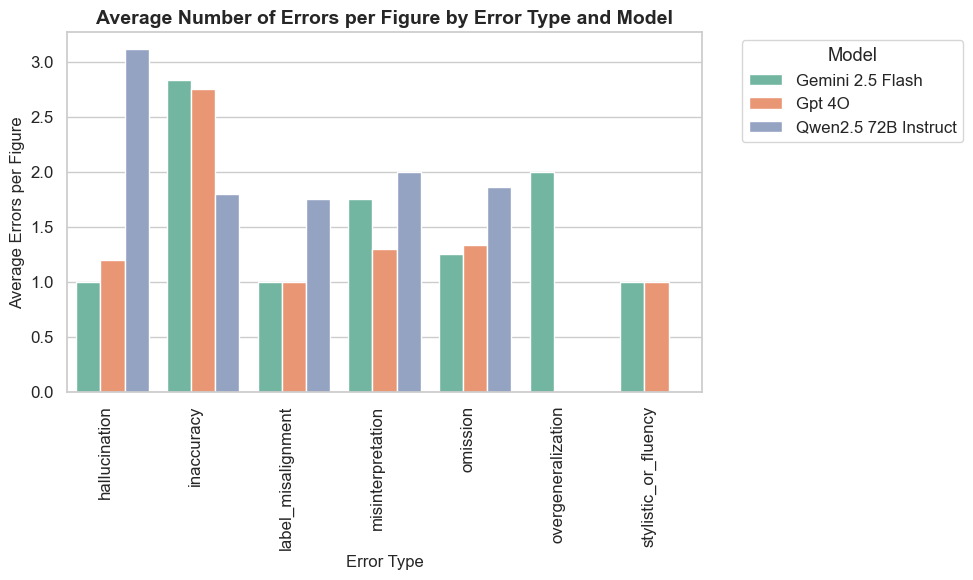

In [3]:
all_models_df = load_error_data(DATA_DIR)
all_models_df = preprocess_error_data(all_models_df)
display(all_models_df.head(5))
error_type_summary = compute_error_type_distribution(all_models_df)
print("\n\n")
display(error_type_summary.head(15))
plot_error_type_distribution(error_type_summary)

In [2]:
def compute_weighted_error_distribution(df: pd.DataFrame) -> pd.DataFrame:
    """Compute average weighted error score per figure and error type."""
    per_fig_type = (
        df.groupby(["model_name", "annotation_id", "detected_error_type"], as_index=False)
        .agg(weighted_error_sum=("weighted_error", "sum"))
    )
    summary = (
        per_fig_type.groupby(["model_name", "detected_error_type"], as_index=False)
        .agg(mean_weighted_error=("weighted_error_sum", "mean"))
    )
    summary.rename(columns={"detected_error_type": "error_type"}, inplace=True)
    return summary

weighted_summary = compute_weighted_error_distribution(all_models_df)



def plot_weighted_error_distribution(summary_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid", font_scale=1.1)
    ax = sns.barplot(
        data=summary_df,
        x="error_type",
        y="mean_weighted_error",
        hue="model_name",
        palette="Set2"
    )

    ax.set_title("Average Severity-Weighted Error Score per Figure by Error Type and Model",
                 fontsize=14, weight="bold")
    ax.set_xlabel("Error Type", fontsize=12)
    ax.set_ylabel("Average Weighted Error per Figure", fontsize=12)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.xticks(rotation=90, ha="right")         # Rotate x-axis labels to prevent overlap

    plt.show()


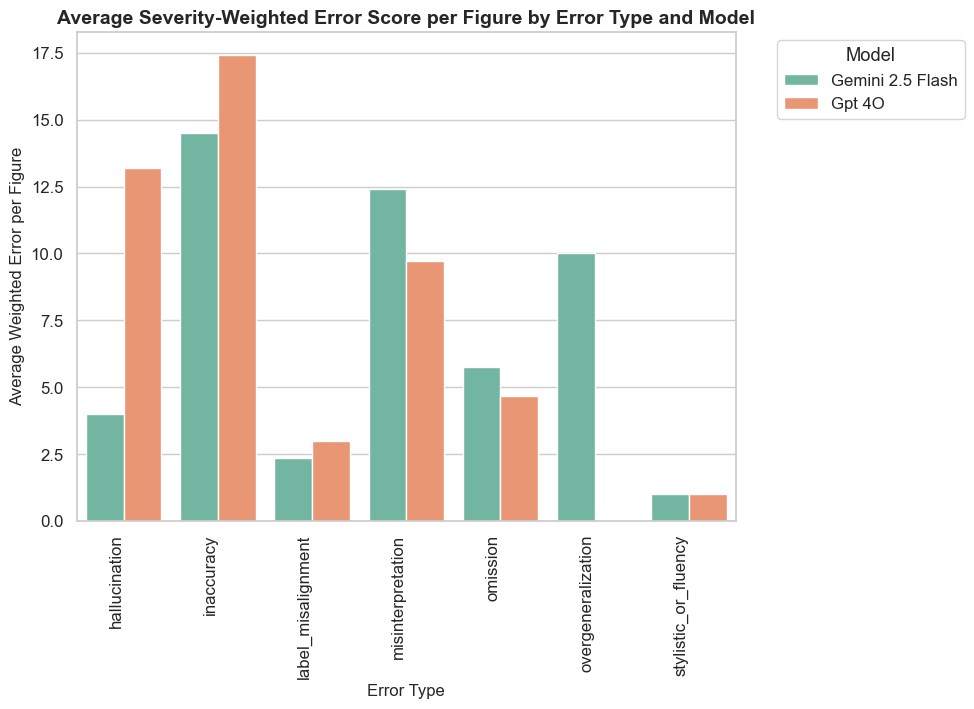

In [9]:

plot_weighted_error_distribution(weighted_summary)

#### Figure 2: _____________________________

In [10]:
# ============================================================
# Figure 2 – Error Location Heatmap (Component × Model)
# ============================================================
# Shows which parts of figures each model struggles with most,
# based on severity-weighted error frequency.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Aggregate component-level weighted errors
# ------------------------------------------------------------
def compute_component_heatmap_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute mean severity-weighted error score per component and model.
    Each cell = average weighted errors per figure for that component.
    """
    # Weighted errors per figure per component
    per_fig_component = (
        df.groupby(["model_name", "annotation_id", "component"], as_index=False)
        .agg(weighted_error_sum=("weighted_error", "sum"))
    )

    # Average across figures per model & component
    summary = (
        per_fig_component.groupby(["component", "model_name"], as_index=False)
        .agg(mean_weighted_error=("weighted_error_sum", "mean"))
    )

    # Pivot for heatmap
    heatmap_data = summary.pivot(index="component", columns="model_name", values="mean_weighted_error")

    # Sort by total mean error to make plot visually meaningful
    heatmap_data["total_mean"] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values("total_mean", ascending=False).drop(columns=["total_mean"])

    return heatmap_data

component_heatmap_data = compute_component_heatmap_data(all_models_df)

# ------------------------------------------------------------
# 2. Plot heatmap
# ------------------------------------------------------------
def plot_component_heatmap(heatmap_df: pd.DataFrame, top_n: int = 20):
    """
    Plot a heatmap of the top N components with highest mean weighted error.
    """
    # Select top N components to keep the figure readable
    plot_df = heatmap_df.head(top_n)

    plt.figure(figsize=(10, max(6, 0.4 * len(plot_df))))
    sns.set(style="whitegrid", font_scale=1.0)
    ax = sns.heatmap(
        plot_df,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        cbar_kws={"label": "Mean Weighted Error per Figure"},
        linewidths=0.3
    )

    ax.set_title(f"Figure 2. Error Locations Across Models (Top {top_n} Components)", fontsize=14, weight="bold")
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Figure Component", fontsize=12)
    plt.tight_layout()
    plt.show()

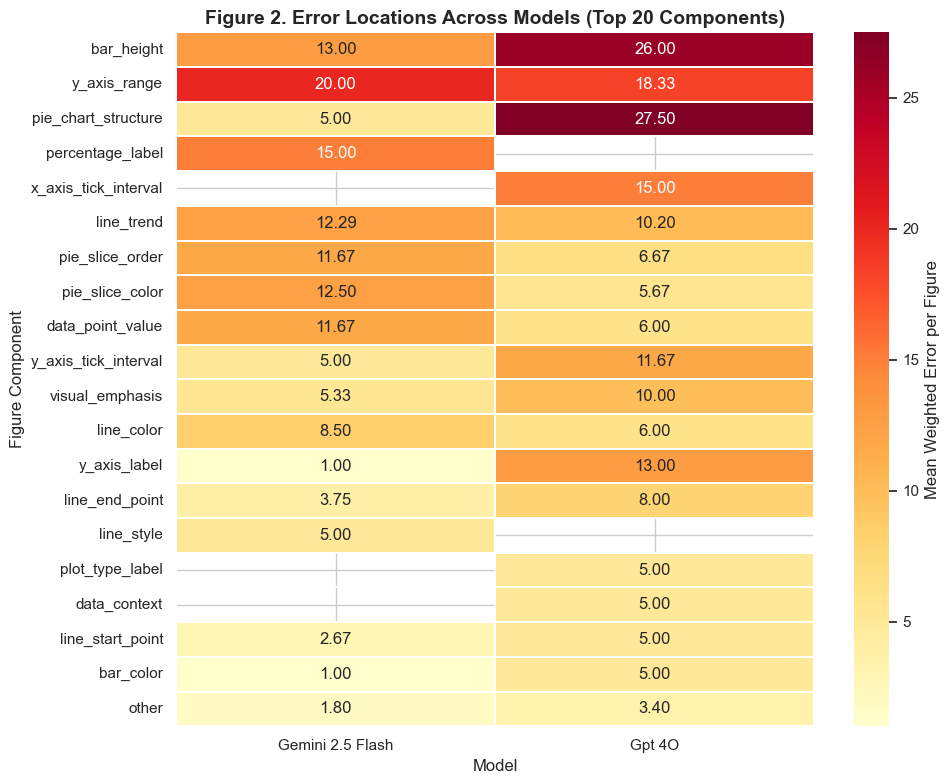

In [11]:

plot_component_heatmap(component_heatmap_data, top_n=20)

#### Figure 3: _____________

In [12]:
# ============================================================
# Figure 3 – Severity Distribution per Model
# ============================================================
# Shows how severe the errors tend to be for each model,
# normalized by figure complexity.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Aggregate per-figure severity-weighted errors
# ------------------------------------------------------------
def compute_per_figure_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute total weighted error per figure (normalized by complexity)
    for each model and figure.
    """
    per_figure = (
        df.groupby(["model_name", "annotation_id", "figure_type"], as_index=False)
        .agg(
            weighted_error_sum=("weighted_error", "sum"),
            figure_complexity=("figure_complexity", "first")
        )
    )

    # Normalize by figure complexity
    per_figure["normalized_error"] = per_figure["weighted_error_sum"] / per_figure["figure_complexity"]
    return per_figure

per_figure_scores = compute_per_figure_scores(all_models_df)

# ------------------------------------------------------------
# 2. Plot: box or violin plot
# ------------------------------------------------------------
def plot_severity_distribution(per_figure_df: pd.DataFrame, kind: str = "box"):
    """
    Plot per-figure normalized error score distribution for each model.
    kind: "box" (default) or "violin"
    """
    plt.figure(figsize=(10, 6))
    sns.set(style="whitegrid", font_scale=1.1)

    if kind == "violin":
        ax = sns.violinplot(
            data=per_figure_df,
            x="model_name",
            y="normalized_error",
            inner="quartile",
            palette="Set2",
            cut=0
        )
    else:
        ax = sns.boxplot(
            data=per_figure_df,
            x="model_name",
            y="normalized_error",
            palette="Set2",
            showfliers=True
        )

    title = (
        "Figure 3. Distribution of Severity-Weighted Error Scores per Figure"
        if kind == "box"
        else "Figure 3. Distribution of Severity-Weighted Error Scores per Figure (Violin Plot)"
    )
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Normalized Severity-Weighted Error per Figure", fontsize=12)
    plt.tight_layout()
    plt.show()


C:\Users\banah\AppData\Local\Temp\ipykernel_38188\926405968.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


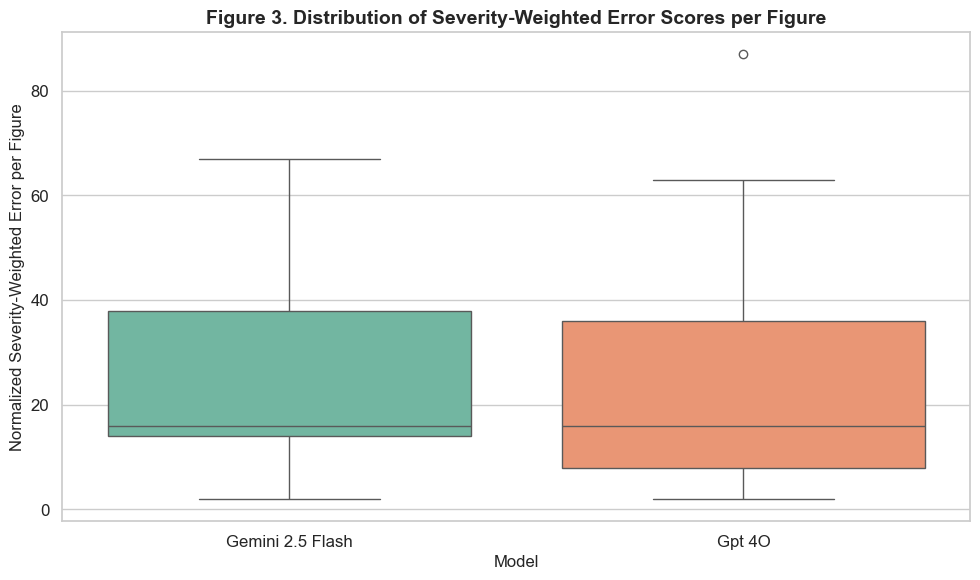

In [13]:

# Choose 'box' for publication clarity, or 'violin' for density insight
plot_severity_distribution(per_figure_scores, kind="box")


#### Figure 4: __________________________

In [1]:
# ============================================================
# Figure 4 – Error Rate by Figure Type
# ============================================================
# Compares average normalized severity-weighted error across
# figure types (e.g., line, bar, pie) for each model.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Compute per-figure error scores (reuse helper if available)
# ------------------------------------------------------------
def compute_per_figure_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute total weighted error per figure (normalized by complexity)
    for each model and figure type.
    """
    per_figure = (
        df.groupby(["model_name", "annotation_id", "figure_type"], as_index=False)
        .agg(
            weighted_error_sum=("weighted_error", "sum"),
            figure_complexity=("figure_complexity", "first")
        )
    )
    per_figure["normalized_error"] = per_figure["weighted_error_sum"] / per_figure["figure_complexity"]
    return per_figure

# Reuse if already defined:
try:
    per_figure_scores
except NameError:
    per_figure_scores = compute_per_figure_scores(all_models_df)

# ------------------------------------------------------------
# 2. Aggregate by figure type
# ------------------------------------------------------------
def compute_error_by_figure_type(per_figure_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute mean normalized error per figure type for each model.
    """
    summary = (
        per_figure_df.groupby(["model_name", "figure_type"], as_index=False)
        .agg(mean_normalized_error=("normalized_error", "mean"))
    )
    return summary

error_by_type_summary = compute_error_by_figure_type(per_figure_scores)

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
def plot_error_by_figure_type(summary_df: pd.DataFrame):
    """Plot grouped bar chart: average normalized errors per figure type."""
    plt.figure(figsize=(8, 5))
    sns.set(style="whitegrid", font_scale=1.1)
    ax = sns.barplot(
        data=summary_df,
        x="figure_type",
        y="mean_normalized_error",
        hue="model_name",
        palette="Set2"
    )

    ax.set_title("Figure 4. Average Severity-Weighted Error per Figure by Figure Type",
                 fontsize=14, weight="bold")
    ax.set_xlabel("Figure Type", fontsize=12)
    ax.set_ylabel("Average Normalized Weighted Error", fontsize=12)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_error_by_figure_type(error_by_type_summary)


NameError: name 'all_models_df' is not defined

In [53]:
# MQM-style TQ scoring for flattened error-analysis JSONs
# --------------------------------------------------------
# This cell:
# 1) Loads one or more flattened JSON files (each row = one detected error)
# 2) Flattens `error_detail` columns
# 3) Computes per-figure MQM-style penalties by category, using model_annotation word count
# 4) Computes per-figure TQ (clamped to [0,100])
# 5) Aggregates into a per-model summary table with mean penalties and Mean/Std TQ
#
# You can add more files to `INPUT_FILES` if you'd like to compare multiple models.

import json
from pathlib import Path
import pandas as pd
import numpy as np
import re

# -----------------------------
# 0) Configuration
# -----------------------------
# Paths you provided; feel free to add more files here
INPUT_FILES = [
    # "/model_evaluation/error_analysis_flattened/gpt_4o_figure_descriptions_with_flattened_error_analysis.json",
    "model_evaluation\error_analysis_flattened\gpt_4o_figure_descriptions_with_flattened_error_analysis.json",
    "model_evaluation\error_analysis_flattened\gemini_2.5_flash_figure_descriptions_with_flattened_error_analysis.json",
    "model_evaluation\error_analysis_flattened\qwen2.5_72b_instruct_figure_descriptions_with_flattened_error_analysis.json"
    # Add more model files here if available, e.g.:
    # "/mnt/data/claude_figure_descriptions_with_flattened_error_analysis.json",
    # "/mnt/data/gemini_figure_descriptions_with_flattened_error_analysis.json",
]

# MQM weights (minor, moderate(=major), critical)
SEVERITY_WEIGHTS = {"minor": 1, "moderate": 5, "critical": 10}

# Canonical error categories -> short codes (for columns)
CATEGORY_CODES = {
    "hallucination": "HP",
    "omission": "OMP",
    "misinterpretation": "MP",
    "inaccuracy": "INP",
    "label_misalignment": "LMP",
    "overgeneralization": "OVP",
    "ambiguity": "AP",
    "stylistic_or_fluency": "SFP",
}

CATEGORY_ORDER = [
    "hallucination",
    "omission",
    "misinterpretation",
    "inaccuracy",
    "label_misalignment",
    "overgeneralization",
    "ambiguity",
    "stylistic_or_fluency",
]

# -----------------------------
# Helpers
# -----------------------------
def load_flattened_files(paths):
    """Load one or more flattened JSON files and add `model_name` from filename if missing."""
    dfs = []
    for p in paths:
        fp = Path(p)
        if not fp.exists():
            print(f"WARNING: File not found: {fp}")
            continue

        df = pd.read_json(fp)

        # Flatten nested error_detail into columns
        if "error_detail" in df.columns:
            details = pd.json_normalize(df["error_detail"])
            df = pd.concat([df.drop(columns=["error_detail"]), details], axis=1)

        # Derive model_name if missing
        if "model_name" not in df.columns or df["model_name"].isna().all():
            stem = fp.stem
            # heuristic cleanup
            model_name = (
                stem.replace("_flattened", "")
                    .replace("_figure_descriptions_with_error_analysis", "")
                    .replace("gpt_4o", "GPT-4o")
                    .replace("_", " ")
                    .strip()
                    .title()
            )
            # Preserve known capitalization quirks
            if model_name.lower() == "Gpt 4O":
                model_name = "GPT-4o"
            df["model_name"] = model_name

        dfs.append(df)

    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


def count_words(text: str) -> int:
    """Simple whitespace-based word count; returns 0 for empty/None."""
    if not isinstance(text, str):
        return 0
    # Strip and split on whitespace
    tokens = re.findall(r"\S+", text)
    return len(tokens)



def compute_per_figure_tq(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute MQM-style per-figure TQ with:
      • 0 penalty for categories with no detected errors
      • Figures with empty model_annotation (word_count == 0) removed entirely
    """
    required = ["model_name", "annotation_id", "model_annotation", "detected_error_type", "error_severity"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Word count per figure
    wc = (
        df.groupby(["model_name", "annotation_id"], as_index=False)["model_annotation"]
          .agg(lambda x: count_words(x.iloc[0]))
          .rename(columns={"model_annotation": "word_count"})
    )

    # Drop empty or missing model_annotation
    wc = wc[wc["word_count"] > 0].copy()

    # Filter out any rows in df for those dropped figures
    df = df.merge(wc[["model_name", "annotation_id"]], on=["model_name", "annotation_id"], how="inner")

    # Severity → numeric weight
    df = df.copy()
    df["severity_weight"] = df["error_severity"].map(SEVERITY_WEIGHTS).fillna(0)

    # Weighted sum per category per figure
    wsum = (
        df.groupby(["model_name", "annotation_id", "detected_error_type"], as_index=False)
          .agg(weighted_sum=("severity_weight", "sum"))
    )

    # Join and pivot
    joined = wc.merge(wsum, on=["model_name", "annotation_id"], how="left")
    pivot = joined.pivot_table(index=["model_name", "annotation_id", "word_count"],
                               columns="detected_error_type",
                               values="weighted_sum",
                               aggfunc="sum",
                               fill_value=0.0).reset_index()

    # Ensure all categories present
    for cat in CATEGORY_ORDER:
        if cat not in pivot.columns:
            pivot[cat] = 0.0

    # Compute penalties (weighted_sum / word_count * 100)
    for cat in CATEGORY_ORDER:
        code = CATEGORY_CODES[cat]
        pivot[code] = (pivot[cat].astype(float) / pivot["word_count"]) * 100.0

    # Compute TQ = 100 - sum(all penalties), clamped to [0,100]
    penalty_cols = [CATEGORY_CODES[c] for c in CATEGORY_ORDER]
    pivot["TQ_raw"] = 100.0 - pivot[penalty_cols].sum(axis=1)
    pivot["TQ"] = pivot["TQ_raw"].clip(0.0, 100.0)

    # Keep only useful columns
    keep = ["model_name", "annotation_id", "word_count"] + penalty_cols + ["TQ"]
    return pivot[keep].copy()



def aggregate_per_model(per_figure_tq: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-model: N_figures_scored, mean penalties per category, mean/std TQ."""
    penalty_cols = [CATEGORY_CODES[c] for c in CATEGORY_ORDER]

    # Filter out figures without a TQ (NaN) as per user's instruction
    scored = per_figure_tq[~per_figure_tq["TQ"].isna()].copy()

    grouped = scored.groupby("model_name", as_index=False).agg(
        N_figures_scored=("annotation_id", "nunique"),
        **{col: (col, "mean") for col in penalty_cols},
        Mean_TQ=("TQ", "mean"),
        Std_TQ=("TQ", "std")
    )

    # Order columns nicely
    cols = ["model_name", "N_figures_scored"] + penalty_cols + ["Mean_TQ", "Std_TQ"]
    grouped = grouped[cols]

    return grouped



In [54]:

# -----------------------------
# 1) Load and compute
# -----------------------------
df_raw = load_flattened_files(INPUT_FILES)
if df_raw.empty:
    per_figure_tq = pd.DataFrame()
    per_model_summary = pd.DataFrame()
else:
    per_figure_tq = compute_per_figure_tq(df_raw)
    per_model_summary = aggregate_per_model(per_figure_tq)

# Display results
# from caas_jupyter_tools import display_dataframe_to_user

if not per_figure_tq.empty:
    print("Per-Figure MQM-style TQ")
    display(per_figure_tq)

if not per_model_summary.empty:
    print("Per-Model MQM-style Summary")
    display(per_model_summary)


Per-Figure MQM-style TQ


detected_error_type,model_name,annotation_id,word_count,HP,OMP,MP,INP,LMP,OVP,AP,SFP,TQ
0,Gemini 2.5 Flash,212,317,0.000000,0.000000,3.154574,4.100946,0.315457,0.000000,0.0,0.315457,92.113565
1,Gemini 2.5 Flash,227,284,0.352113,1.760563,0.000000,0.000000,0.000000,0.000000,0.0,0.352113,97.535211
2,Gemini 2.5 Flash,228,278,0.000000,0.000000,0.000000,1.079137,0.000000,3.597122,0.0,0.359712,94.964029
3,Gemini 2.5 Flash,230,179,2.793296,0.558659,2.793296,1.675978,0.000000,0.000000,0.0,0.000000,92.178771
4,Gemini 2.5 Flash,300,279,0.000000,0.716846,0.000000,10.752688,1.792115,0.000000,0.0,0.000000,86.738351
5,Gemini 2.5 Flash,447,121,4.132231,4.132231,4.132231,0.000000,0.000000,0.000000,0.0,0.000000,87.603306
6,Gemini 2.5 Flash,449,151,0.000000,0.000000,9.933775,0.662252,0.000000,0.000000,0.0,0.000000,89.403974
7,Gemini 2.5 Flash,590,193,0.518135,0.518135,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,98.963731
8,Gemini 2.5 Flash,626,144,3.472222,6.944444,0.000000,22.222222,0.000000,0.000000,0.0,0.000000,67.361111
9,Gemini 2.5 Flash,679,180,2.777778,0.000000,0.555556,2.777778,0.000000,0.000000,0.0,0.000000,93.888889


Per-Model MQM-style Summary


,model_name,N_figures_scored,HP,OMP,MP,INP,LMP,OVP,AP,SFP,Mean_TQ,Std_TQ
0,Gemini 2.5 Flash,17,1.323915,1.062717,3.744325,4.026358,0.147790,0.211595,0.0,0.119258,89.364042,7.230468
1,Gpt-4O,17,1.717681,2.375556,2.550916,4.715241,0.184064,0.000000,0.0,0.071059,88.385483,6.474335
2,Qwen2.5 72B Instruct,17,16.396228,5.957758,8.468257,1.681644,1.861803,0.000000,0.0,0.000000,65.634310,18.187433


#### Prepare Error Analysis for Evaluation in Label Studio

In [109]:
# Create Label-studio-ready dataset

wrap_entries_for_label_studio(
    input_path=f"{ERROR_ANALYSIS_EVAL_DIR}/{'flattened_detected_errors.json'}",
    output_path=f"{ERROR_ANALYSIS_EVAL_DIR}/{'error_detection_evaluation_label_studio_import.json'}"
)

✅ Label Studio-ready dataset saved to: auto_error_analysis_evaluation/error_detection_evaluation_label_studio_import.json


#### Reformat Label Studio Export after Labelling

In [110]:
import json

def reformat_detection_evaluation_project_export(input_path, output_path):
    
    with open(input_path, "r", encoding="utf-8") as f:
        loaded_json = json.load(f)

    reformatted_data = []

    for item in loaded_json:
        data = item.get("data", {})
        completion = item.get("annotations", [])[0]  # assuming single annotation per item
        result = completion.get("result", [])

        eval_entry = {
            "is_true_error": None,
            "appropriate_error_category_label": None,
            "appropriate_severity_rating": None,
            "comment": None
        }

        for r in result:
            value = r.get("value", {})
            from_name = r.get("from_name", "")

            if from_name == "is_true_error":
                eval_entry["is_true_error"] = value.get("choices", [None])[0]
            elif from_name == "appropriate_error_category":
                eval_entry["appropriate_error_category_label"] = value.get("choices", [None])[0]
            elif from_name == "appropriate_severity_rating":
                eval_entry["appropriate_severity_rating"] = value.get("choices", [None])[0]
            elif from_name == "human_annotation":
                eval_entry["comment"] = value.get("text", [None])[0]
        
        data["detection_eval"] = eval_entry
        reformatted_data.append(data)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(reformatted_data, f, indent=2, ensure_ascii=False)
        print(f"Saved {len(reformatted_data)} detected instances of errors with corresponding human evaluations")

    return reformatted_data

In [111]:
# Load the files
detected_errors_path = f"{'auto_error_analysis_evaluation'}/{'flattened_detected_errors.json'}"
ls_export_path = f"{'auto_error_analysis_evaluation'}/{'error_detection_analysis_project_export.json'}"
output_path = f"{'auto_error_analysis_evaluation'}/{'evaluated_detected_errors.json'}"

reformat_detection_evaluation_project_export(input_path=ls_export_path, output_path=output_path)

Saved 260 detected instances of errors with corresponding human evaluations


[{'caption': 'Average cosine similarity between generated training samples (K=32) for each relation category.',
  'task_id': 56,
  'arxiv_id': '2505.23108v1',
  'annotation': 'The line plot illustrates the mean interclass similarity across different relation categories. The x-axis is labeled "Relation Category" and has a linear scale, ranging from approximately 0 to 60 with tick marks at intervals of 10. The y-axis is labeled "Mean Interclass Similarity" and has a linear scale, ranging from 0.0 to 0.5 with tick marks at intervals of 0.1. The plot contains three primary lines. The first line is blue with circle markers and a solid style, representing "w/o DPO obo." It starts at approximately (0, 0.2), peaking around 2nd and 31st categories, and fluctuates across the axis, ending near 0.0. The second line is orange with triangle markers and a solid style, representing "w/o DPO obo & w/o div-hint." It starts at 0.1 for 0 category, peaks multiple times with the highest point around 0.47 ne

#### Analyse Error Detection Correctness Evaluation Results

In [112]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_evaluated_dataset(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return pd.DataFrame(data)


def compute_detection_correctness_stats(df):
    evaluated_df = df[df["detection_eval"].notnull()].copy()

    evaluated_df["is_true_error"] = evaluated_df["detection_eval"].apply(lambda x: x.get("is_true_error"))
    evaluated_df["category_human"] = evaluated_df["detection_eval"].apply(lambda x: x.get("appropriate_error_category_label"))
    evaluated_df["severity_human"] = evaluated_df["detection_eval"].apply(lambda x: x.get("appropriate_severity_rating"))
    evaluated_df["comment"] = evaluated_df["detection_eval"].apply(lambda x: x.get("comment"))

    evaluated_df["category_model"] = evaluated_df["detected_error_type"]
    evaluated_df["severity_model"] = evaluated_df["error_detail"].apply(lambda x: x.get("error_severity") if x else None)

    total = len(evaluated_df)
    true_error_rate = (evaluated_df["is_true_error"] == "Yes").mean()
    false_error_rate = (evaluated_df["is_true_error"] == "No").mean()
    category_agreement = (evaluated_df["category_model"] == evaluated_df["category_human"]).mean()
    severity_agreement = (evaluated_df["severity_model"] == evaluated_df["severity_human"]).mean()
    comment_rate = evaluated_df["comment"].notnull().mean()

    summary_stats = {
        "total_evaluated": total,
        "true_error_rate": true_error_rate,
        "false_error_rate": false_error_rate,
        "category_agreement": category_agreement,
        "severity_agreement": severity_agreement,
        "comment_rate": comment_rate,
    }

    return evaluated_df, summary_stats


def compute_per_type_accuracy(df):
    per_type = df.groupby("category_model").agg(
        total=("is_true_error", "count"),
        true_detections=("is_true_error", lambda x: (x == "Yes").sum()),
        category_matches=("category_human", lambda x: (x == x.name).sum()),
        severity_matches=("severity_human", lambda x: (x == df.loc[x.index, "severity_model"]).sum())
    )

    per_type["true_detection_rate"] = per_type["true_detections"] / per_type["total"]
    per_type["category_match_rate"] = per_type["category_matches"] / per_type["total"]
    per_type["severity_match_rate"] = per_type["severity_matches"] / per_type["total"]

    return per_type.reset_index()


def plot_confusion_matrix(df, col_true, col_pred, title):
    confusion = pd.crosstab(df[col_true], df[col_pred], dropna=False)
    plt.figure(figsize=(10, 6))
    sns.heatmap(confusion, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(title)
    plt.xlabel("Model Prediction")
    plt.ylabel("Human Label")
    plt.tight_layout()
    plt.show()


def plot_accuracy_bars(per_type_df):
    melted = per_type_df.melt(id_vars="category_model",
                               value_vars=["true_detection_rate", "category_match_rate", "severity_match_rate"],
                               var_name="metric", value_name="rate")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=melted, x="category_model", y="rate", hue="metric")
    plt.title("Accuracy Metrics per Error Type")
    plt.xticks(rotation=45)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


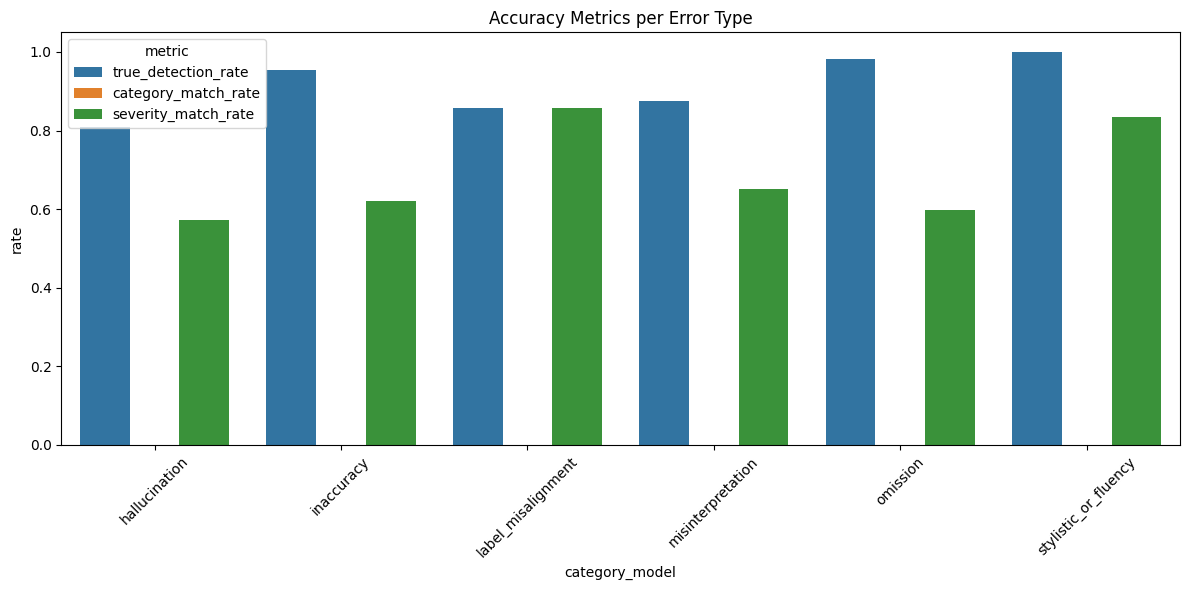

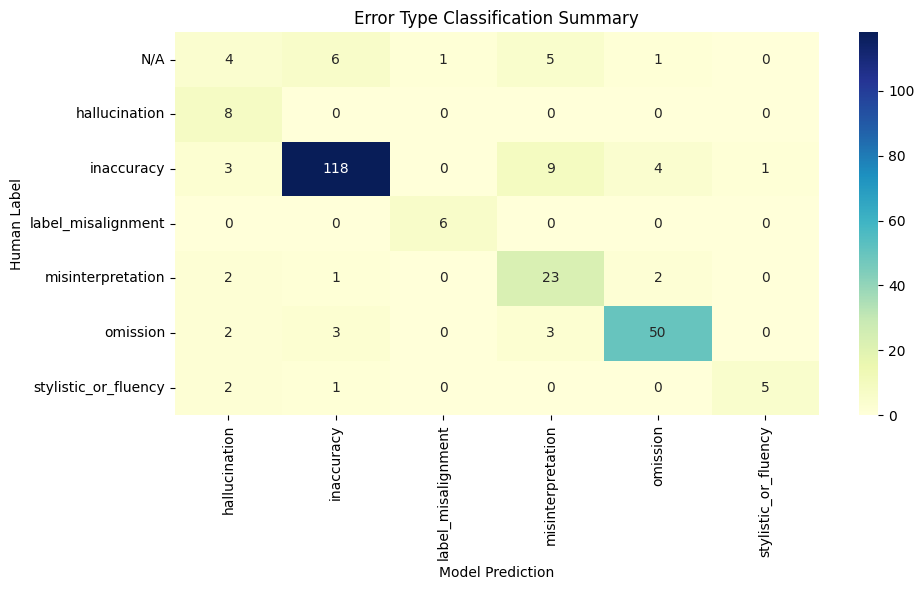

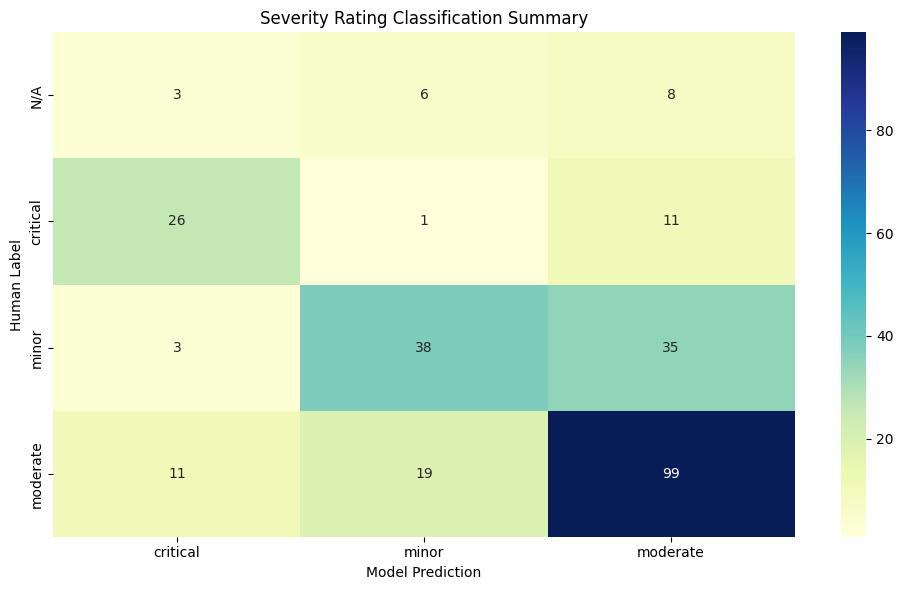

{'total_evaluated': 260, 'true_error_rate': 0.9346153846153846, 'false_error_rate': 0.06538461538461539, 'category_agreement': 0.8076923076923077, 'severity_agreement': 0.6269230769230769, 'comment_rate': 0.015384615384615385}


,category_model,total,true_detections,category_matches,severity_matches,true_detection_rate,category_match_rate,severity_match_rate
0,hallucination,21,17,0,12,0.809524,0.0,0.571429
1,inaccuracy,129,123,0,80,0.953488,0.0,0.620155
2,label_misalignment,7,6,0,6,0.857143,0.0,0.857143
3,misinterpretation,40,35,0,26,0.875000,0.0,0.650000
4,omission,57,56,0,34,0.982456,0.0,0.596491
5,stylistic_or_fluency,6,6,0,5,1.000000,0.0,0.833333


In [113]:
df = load_evaluated_dataset(f"{'auto_error_analysis_evaluation'}/{'evaluated_detected_errors.json'}")
evaluated_df, summary_stats = compute_detection_correctness_stats(df)
per_type_df = compute_per_type_accuracy(evaluated_df)

# Visualization
plot_accuracy_bars(per_type_df)
plot_confusion_matrix(evaluated_df, "category_human", "category_model", "Error Type Classification Summary")
plot_confusion_matrix(evaluated_df, "severity_human", "severity_model", "Severity Rating Classification Summary")

# Optional: Display stats
print(summary_stats)
display(per_type_df)


## Testing Reproducibility of Error Analysis

#### Setup Test Execution Code

In [114]:
import json
import logging
from collections import Counter
from typing import List, Dict, Any
from tqdm import tqdm
from pathlib import Path


def compute_jaccard(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union else 1.0

def compute_weighted_jaccard(c1: Counter, c2: Counter):
    keys = set(c1.keys()) | set(c2.keys())
    intersection = sum(min(c1[k], c2[k]) for k in keys)
    union = sum(max(c1[k], c2[k]) for k in keys)
    return intersection / union if union else 1.0

def compute_reproducibility_metrics(error_counts: List[Dict[str, int]]) -> Dict[str, Any]:
    n = len(error_counts)
    count_deltas = Counter()
    jaccard_sims = []
    weighted_jaccard_sims = []

    for i in range(n):
        for j in range(i + 1, n):
            c1 = Counter(error_counts[i])
            c2 = Counter(error_counts[j])

            # Count deltas
            all_keys = set(c1) | set(c2)
            for k in all_keys:
                count_deltas[k] += abs(c1.get(k, 0) - c2.get(k, 0))

            # Jaccard similarity
            jaccard_sims.append(compute_jaccard(set(c1), set(c2)))

            # Weighted Jaccard
            weighted_jaccard_sims.append(compute_weighted_jaccard(c1, c2))

    total_pairs = n * (n - 1) / 2 or 1
    return {
        "mean_jaccard_similarity": sum(jaccard_sims) / total_pairs,
        "mean_weighted_jaccard_similarity": sum(weighted_jaccard_sims) / total_pairs,
        "average_error_count_deltas": {
            k: v / total_pairs for k, v in count_deltas.items()
        }
    }

def run_reproducibility_test(
    input_path: str,
    output_path: str,
    model: str = "gpt-4o",
    n_runs: int = 5
):
    with open(input_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    results = []
    for entry in tqdm(data, desc="Testing reproducibility"):
        model_annotation = entry.get("model_annotation")
        human_annotation = entry.get("annotation")

        raw_responses = []
        error_counts = []

        for _ in range(n_runs):
            try:
                response = get_error_analysis_response(
                    model_annotation, human_annotation, model=model
                )
                raw_responses.append(response)
                counts = response.get("error_analysis", {}).get("counts", {})
                error_counts.append(counts)
            except Exception as e:
                logging.warning(f"Error: {e}")
                continue

        reproducibility_stats = compute_reproducibility_metrics(error_counts)
        entry_result = {
            "annotation": entry,
            "raw_responses": raw_responses,
            "reproducibility": reproducibility_stats,
        }
        results.append(entry_result)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Reproducibility results saved to: {output_path}")

In [115]:
# Run Tests
run_reproducibility_test(
    input_path=f"{'auto_error_analysis_evaluation'}/{ANNOTATION_SEPARATED_DATASET_SAMPLE_FOR_TESTS_FILENAME}",
    output_path=f"{'auto_error_analysis_evaluation'}/{'reproducibility_test_results.json'}",
    n_runs=10
)

Testing reproducibility:  11%|█         | 10/93 [38:48<5:22:06, 232.85s/it]


KeyboardInterrupt: 

#### Analysing Results

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import defaultdict, Counter
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# === Load Data ===
def load_reproducibility_data(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

# === Compute Statistics ===
# def compute_error_count_stats(annotation):
def compute_error_count_stats(annotation_test_entry):
    counts_list = [resp["error_analysis"]["counts"] for resp in annotation_test_entry["raw_responses"]]
    all_error_types = sorted(set(k for counts in counts_list for k in counts.keys()))
    df = pd.DataFrame([{k: counts.get(k, 0) for k in all_error_types} for counts in counts_list])
    
    stats = {
        "annotation_id": annotation_test_entry["annotation"].get("annotation_id", None),
        "task_id": annotation_test_entry["annotation"].get("task_id", None),
        "annotated_by": annotation_test_entry["annotation"].get("annotated_by", None),
        "figure_type": annotation_test_entry["annotation"].get("figure_type", None),
        "jaccard_avg": compute_average_jaccard(counts_list),
        "weighted_jaccard_avg": compute_average_weighted_jaccard(counts_list),
        "count_l1_avg": compute_average_l1_distance(df.values),
        "count_cosine_avg": compute_average_cosine_similarity(df.values)
    }
    
    # Add variance for each error type
    for error_type in all_error_types:
        stats[f"var_{error_type}"] = df[error_type].var()

    return stats, df

def compute_average_jaccard(counts_list):
    sets = [set(k for k, v in d.items() if v > 0) for d in counts_list]
    if len(sets) < 2:
        return 1.0
    jaccards = [
        len(s1 & s2) / len(s1 | s2) if s1 | s2 else 1.0
        for s1, s2 in combinations(sets, 2)
    ]
    return np.mean(jaccards)

def compute_average_weighted_jaccard(counts_list):
    if len(counts_list) < 2:
        return 1.0
    jaccards = []
    for d1, d2 in combinations(counts_list, 2):
        keys = set(d1.keys()) | set(d2.keys())
        min_sum = sum(min(d1.get(k, 0), d2.get(k, 0)) for k in keys)
        max_sum = sum(max(d1.get(k, 0), d2.get(k, 0)) for k in keys)
        jaccards.append(min_sum / max_sum if max_sum > 0 else 1.0)
    return np.mean(jaccards)

def compute_average_l1_distance(matrix):
    if len(matrix) < 2:
        return 0.0
    dists = [np.sum(np.abs(a - b)) for a, b in combinations(matrix, 2)]
    return np.mean(dists)

def compute_average_cosine_similarity(matrix):
    if len(matrix) < 2:
        return 1.0
    sim = cosine_similarity(matrix)
    indices = np.triu_indices_from(sim, k=1)
    return np.mean(sim[indices])

# === Run and Aggregate ===
def analyze_reproducibility(data):
    all_stats = []
    all_error_vectors = []

    for entry in data:
        stats, error_vector_df = compute_error_count_stats(entry)
        all_stats.append(stats)
        all_error_vectors.append(error_vector_df.values)

    return pd.DataFrame(all_stats), all_error_vectors

# === Visualizations ===


def plot_boxplot_variances(stats_df):
    var_cols = [col for col in stats_df.columns if col.startswith("var_")]
    melted = stats_df.melt(value_vars=var_cols,
                           var_name="error_type", value_name="variance")
    melted["error_type"] = melted["error_type"].str.replace("var_", "")

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=melted, x="error_type", y="variance")
    plt.title("Boxplot of Error Count Variances")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_heatmap_of_similarity(error_vectors, index_labels=None):
    flattened = [vec.flatten() for vec in error_vectors]
    sim = cosine_similarity(flattened)

    plt.figure(figsize=(8, 6))
    sns.heatmap(sim, xticklabels=index_labels, yticklabels=index_labels,
                cmap="Blues", annot=True, fmt=".2f")
    plt.title("Cosine Similarity of Error Count Vectors")
    plt.tight_layout()
    plt.show()
    

def plot_pca(error_vectors):
    flattened = [vec.flatten() for vec in error_vectors]
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(flattened)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1])
    plt.title("PCA of Error Count Vectors")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


def full_reproducibility_analysis(input_path):
    data = load_reproducibility_data(input_path)
    stats_df, error_vectors = analyze_reproducibility(data)

    # tools.display_dataframe_to_user(name="Reproducibility Stats", dataframe=stats_df)
    display(stats_df)

    # plot_error_type_variances(stats_df)           # TODO: Check why this function is missing
    plot_boxplot_variances(stats_df)

    index_labels = [entry["annotation"]["annotation_id"] for entry in data[:10]]
    # plot_heatmap_of_similarity(error_vectors[:10], index_labels=index_labels)
    # plot_pca(error_vectors[:100])

    return stats_df

,annotation_id,task_id,annotated_by,figure_type,jaccard_avg,weighted_jaccard_avg,count_l1_avg,count_cosine_avg,var_ambiguity,var_hallucination,var_inaccuracy,var_label_misalignment,var_misinterpretation,var_omission,var_overgeneralization,var_stylistic_or_fluency
0,1151,217,8,Line Plot,1.000000,0.942857,0.400000,0.998166,0.0,0.000000,0.100000,0.0,0.000000,0.100000,0.0,0.0
1,244,60,9,Line Plot,1.000000,0.928889,0.355556,0.998953,0.0,0.000000,0.177778,0.0,0.000000,0.000000,0.0,0.0
2,272,91,10,Line Plot,0.933333,0.966667,0.200000,0.992725,0.0,0.100000,0.000000,0.0,0.000000,0.000000,0.0,0.0
3,575,937,9,Line Plot,1.000000,0.966667,0.200000,0.999774,0.0,0.000000,0.100000,0.0,0.000000,0.000000,0.0,0.0
4,233,65,11,Line Plot,1.000000,1.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,436,45,10,Pie Chart,1.000000,0.796164,1.400000,0.956577,0.0,0.000000,0.233333,0.0,0.233333,0.233333,0.0,0.0
89,445,1217,11,Pie Chart,1.000000,1.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0
90,1209,1980,8,Flow Diagram,0.960000,0.871605,1.066667,0.962469,0.0,0.233333,0.222222,0.1,0.000000,0.000000,0.0,0.0
91,438,176,11,Flow Diagram,1.000000,0.868642,1.288889,0.961990,0.0,0.266667,0.400000,0.0,0.000000,0.177778,0.0,0.0


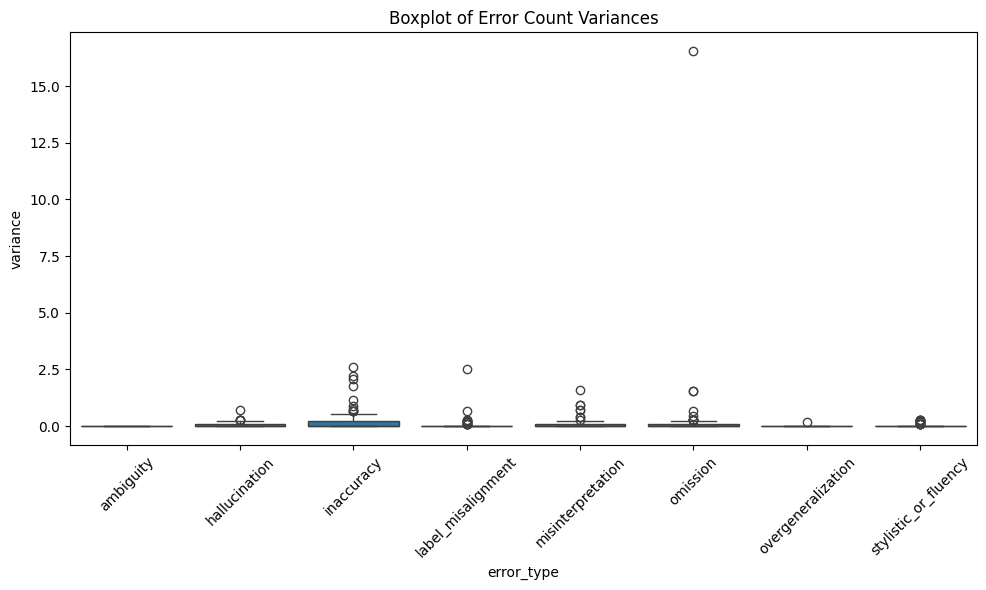

In [ ]:
stats_df = full_reproducibility_analysis(input_path=f"{'auto_error_analysis_evaluation'}/{'reproducibility_test_results.json'}")

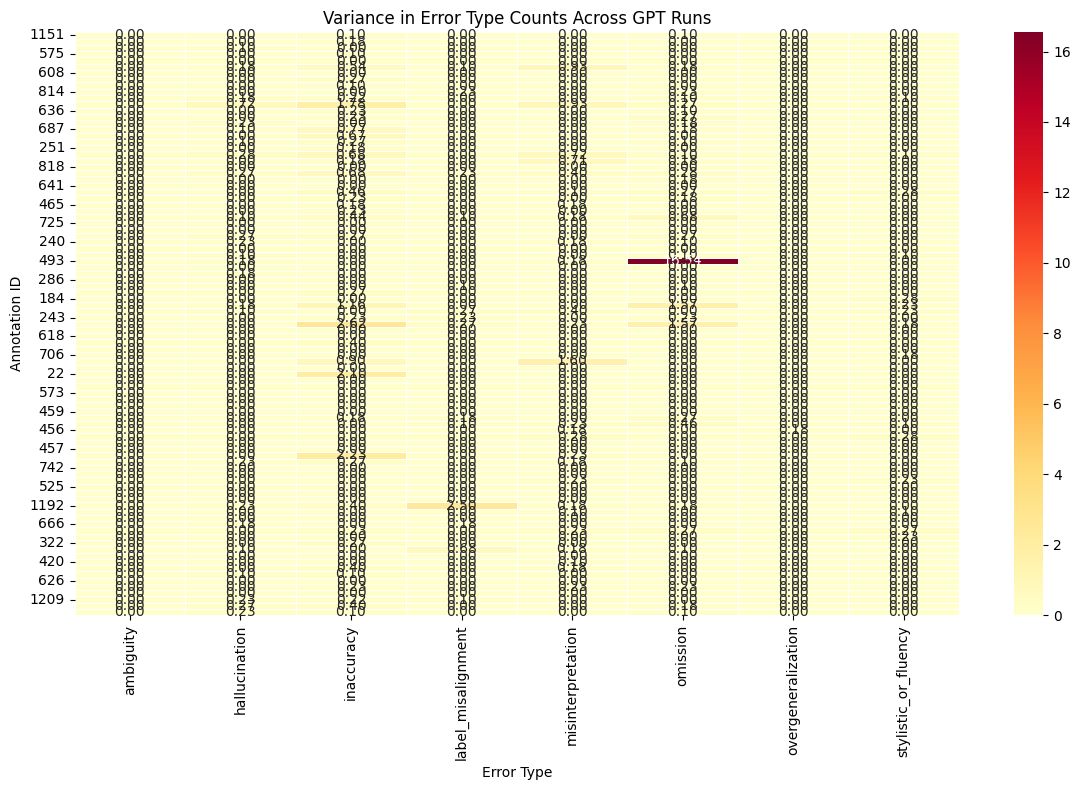

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_variance_heatmap(stats_df):
    # Extract just the variance columns
    var_cols = [col for col in stats_df.columns if col.startswith("var_")]
    
    # Create the heatmap data
    heatmap_data = stats_df[var_cols]
    heatmap_data.index = stats_df["annotation_id"]

    # Rename columns to be cleaner
    heatmap_data.columns = [col.replace("var_", "") for col in heatmap_data.columns]

    # Plot
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
    plt.title("Variance in Error Type Counts Across GPT Runs")
    plt.xlabel("Error Type")
    plt.ylabel("Annotation ID")
    plt.yticks(rotation=0)  # ← Set y-axis labels to horizontal
    plt.tight_layout()
    plt.show()


plot_variance_heatmap(stats_df=stats_df)

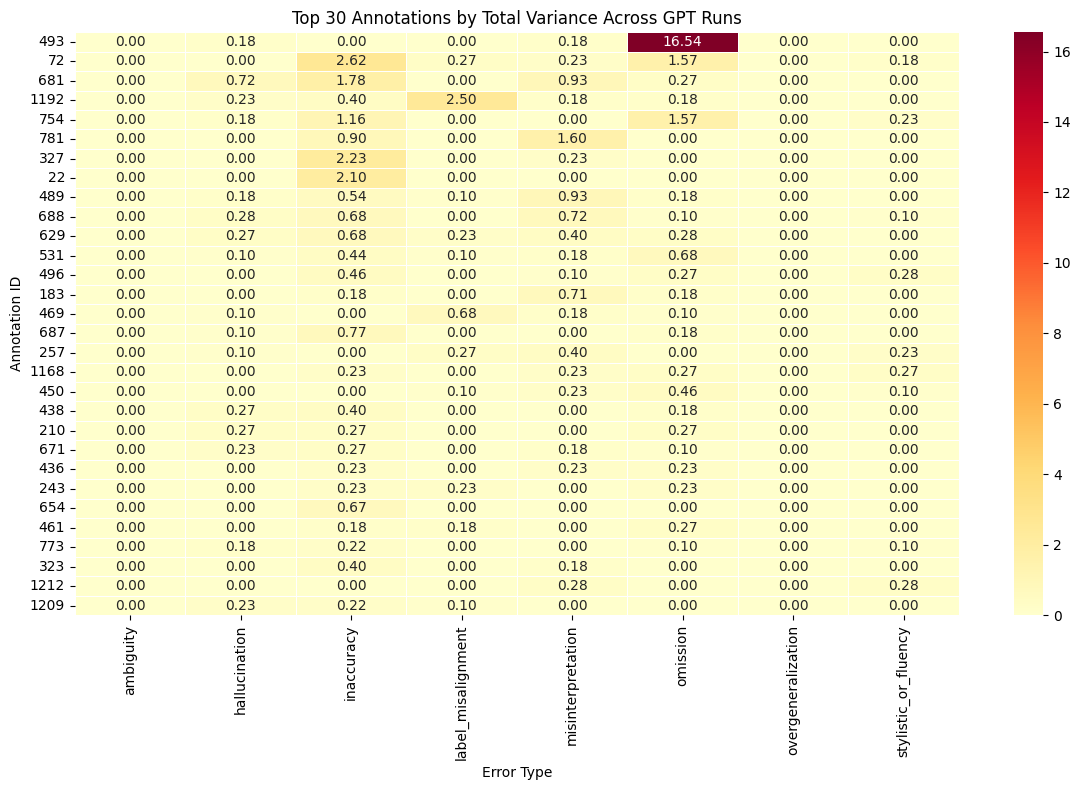

In [ ]:
def plot_topk_variance_heatmap(stats_df, top_k=25):
    var_cols = [col for col in stats_df.columns if col.startswith("var_")]
    stats_df["total_variance"] = stats_df[var_cols].sum(axis=1)
    
    topk_df = stats_df.nlargest(top_k, "total_variance")

    heatmap_data = topk_df[var_cols]
    heatmap_data.index = topk_df["annotation_id"]
    heatmap_data.columns = [col.replace("var_", "") for col in heatmap_data.columns]

    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
    plt.title(f"Top {top_k} Annotations by Total Variance Across GPT Runs")
    plt.xlabel("Error Type")
    plt.ylabel("Annotation ID")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


plot_topk_variance_heatmap(stats_df, top_k=30)

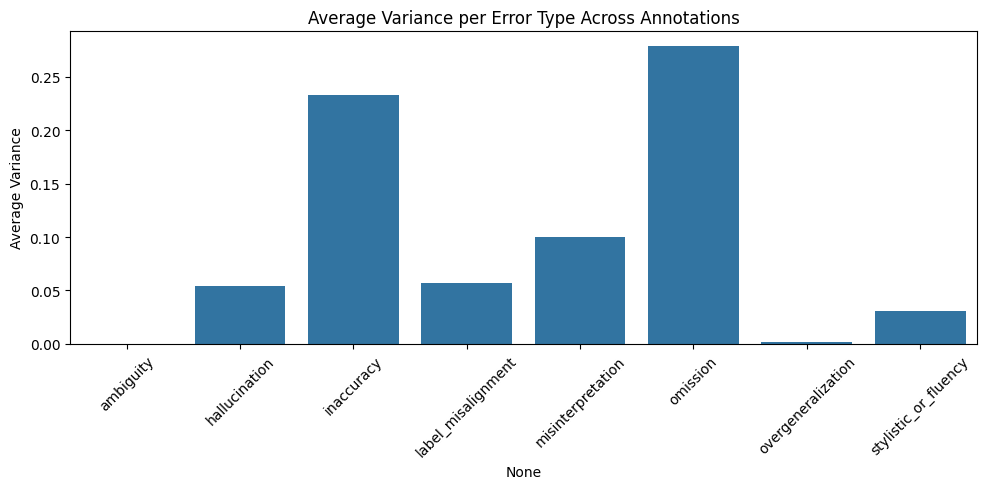

In [ ]:
def plot_error_type_variance_summary(stats_df):
    var_cols = [col for col in stats_df.columns if col.startswith("var_")]
    avg_variances = stats_df[var_cols].mean().rename(lambda x: x.replace("var_", ""))
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=avg_variances.index, y=avg_variances.values)
    plt.title("Average Variance per Error Type Across Annotations")
    plt.ylabel("Average Variance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_error_type_variance_summary(stats_df)

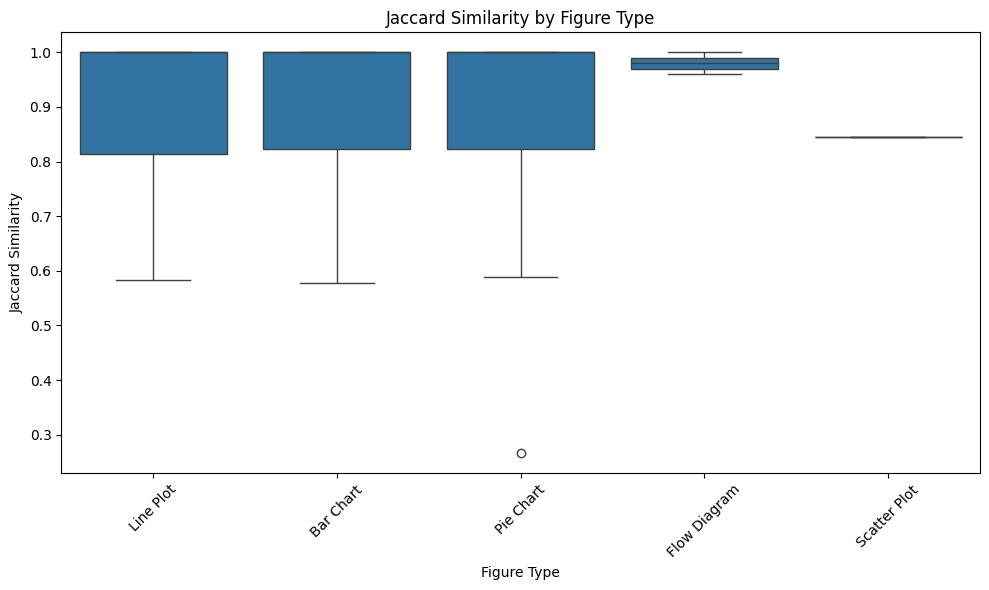

(93, 16)


In [ ]:
def plot_jaccard_by_figure_type(stats_df):
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=stats_df, x="figure_type", y="jaccard_avg")
    plt.title("Jaccard Similarity by Figure Type")
    plt.ylabel("Jaccard Similarity")
    plt.xlabel("Figure Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_jaccard_by_figure_type(stats_df=stats_df)
print(stats_df.shape)

# Auto-Error-Detection-Based Inter-Annotator Agreement

#### Create new annotations sample by Selecting Annotations from Flattened Dataset for 75 Required Figures for all annotators

In [49]:
required_figure_ids = {1, 2, 3, 4, 5, 6, 7, 25, 30, 32, 40, 41, 42,43, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
                       64, 65, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 234, 235, 236, 237, 238, 239, 290, 291, 292, 293,
                       156, 157, 201, 204, 217, 218, 249, 45, 176, 178, 241, 242, 243, 244, 245, 1216, 1217, 1218, 1219, 1220,
                       1221, 1222, 1223, 1224, 1225, 1226}

print(f"There are {len(required_figure_ids)} required tasks for all annotators.")

There are 77 required tasks for all annotators.


In [56]:
from __future__ import annotations
import json
from pathlib import Path
from typing import Iterable, Any, List, Dict

def filter_by_task_ids_and_language(input_json_path: str | Path,
                       output_json_path: str | Path,
                       task_ids: Iterable[Any],
                       languages: Iterable = {}) -> Dict:
    
    input_json_path = Path(input_json_path)
    output_json_path = Path(output_json_path)

    # Normalize the allowed IDs to strings so we match ints/strings seamlessly.
    allowed = {str(x).strip() for x in task_ids}

    with input_json_path.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if not isinstance(data, list):
        raise ValueError("Input JSON must be a top-level list of entries.")

    # Keep only dict entries whose 'task_id' (as string) is in allowed set
    filtered: List[Dict[str, Any]] = []
    for item in data:
        if isinstance(item, dict) and "task_id" in item:
            # Include only listed languages if specified
            if languages and item["annotation_language"] not in languages:
                continue
            if str(item["task_id"]).strip() in allowed:
                filtered.append(item)
    
    # Rename key from gpt_annotation → model_annotation if it exists        # TODO: MOVE TO EARLIER POINT IN PIPELINE
    for entry in filtered:
        if "gpt_annotation" in entry:
            entry["model_annotation"] = entry.pop("gpt_annotation")

    with output_json_path.open("w", encoding="utf-8") as f:
        json.dump(filtered, f, ensure_ascii=False, indent=2)

    # return len(filtered)
    return filtered

In [57]:
kept = filter_by_task_ids_and_language(
    input_json_path=f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_ANNOTATION_INDIVIDUALIZED_DATASET_FILENAME}",
    output_json_path=f"{'annotator_overlap'}/{'required_annotations.json'}",
    task_ids=required_figure_ids,
    languages="English"
)
print(f"Wrote {len(kept)} entries.")

Wrote 292 entries.


#### Run Reproducibility Tests

In [58]:
# Run Tests
run_reproducibility_test(
    input_path=f"{'annotator_overlap'}/{'required_annotations.json'}",
    output_path=f"{'annotator_overlap'}/{'required_annotations_with_error_analysis.json'}",
    n_runs=10
)

Testing reproducibility:  39%|███▉      | 115/292 [3:16:29<5:38:16, 114.67s/it]WARNING:__main__:OpenAI API error on attempt 1: Connection error.
CRITICAL:__main__:Max retries reached. Aborting.
CRITICAL:__main__:Max retries reached. Aborting.
CRITICAL:__main__:Max retries reached. Aborting.
CRITICAL:__main__:Max retries reached. Aborting.
CRITICAL:__main__:Max retries reached. Aborting.
CRITICAL:__main__:Max retries reached. Aborting.
Testing reproducibility:  40%|███▉      | 116/292 [3:20:28<7:25:51, 152.00s/it]WARNING:__main__:OpenAI API error on attempt 1: Connection error.
CRITICAL:__main__:Max retries reached. Aborting.
Testing reproducibility: 100%|██████████| 292/292 [7:45:22<00:00, 95.63s/it]   



✅ Reproducibility results saved to: annotator_overlap/required_annotations_with_error_analysis.json


#### Load and structure the raw reproducibility data

In [132]:
import json
import pandas as pd
from collections import defaultdict

def load_flattened_error_counts(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Flatten to per-annotation summary with averaged error type counts
    records = []
    for entry in data:
        task_id = entry["annotation"].get("task_id")
        annotator_id = entry["annotation"].get("annotated_by")
        annotation_id = entry["annotation"].get("annotation_id")

        runs = entry.get("raw_responses", [])
        if not runs:
            continue

        # Collect counts per run
        all_counts = [r["error_analysis"]["counts"] for r in runs]
        error_types = all_counts[0].keys()

        # Average counts per error type
        avg_counts = {
            error_type: sum(c[error_type] for c in all_counts) / len(all_counts)
            for error_type in error_types
        }

        record = {
            "task_id": task_id,
            "annotated_by": annotator_id,
            "annotation_id": annotation_id,
            **avg_counts
        }
        records.append(record)

    return pd.DataFrame(records)


def compute_inter_annotator_variance(df):
    error_cols = [col for col in df.columns if col not in {"task_id", "annotated_by", "annotation_id"}]

    # Group by task, compute variance per error type
    grouped = df.groupby("task_id")[error_cols].agg(["var", "count"])
    
    # Flatten MultiIndex columns
    grouped.columns = [f"{col}_{stat}" for col, stat in grouped.columns]
    grouped.reset_index(inplace=True)
    return grouped


def get_annotation_coverage(df):
    pivot = df.pivot_table(index="task_id", columns="annotated_by", values="annotation_id", aggfunc="count")
    coverage = pivot.notnull().astype(int)
    return coverage


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_inter_annotator_variance_heatmap(var_df):
    var_cols = [col for col in var_df.columns if col.endswith("_var")]
    heatmap_data = var_df[["task_id"] + var_cols].set_index("task_id")

    # Rename cols to drop "_var"
    heatmap_data.columns = [col.replace("_var", "") for col in heatmap_data.columns]

    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".2f")
    plt.title("Inter-Annotator Variance per Error Type (by Task)")
    plt.xlabel("Error Type")
    plt.ylabel("Task ID")
    plt.tight_layout()
    plt.show()


In [61]:
def plot_annotation_coverage(coverage_df):
    plt.figure(figsize=(10, 6))
    sns.heatmap(coverage_df, cmap="Greens", linewidths=0.5, linecolor="gray", cbar=False, annot=True, fmt="d")
    plt.title("Annotator Coverage per Task (1 = annotated)")
    plt.xlabel("Annotator ID")
    plt.ylabel("Task ID")
    plt.tight_layout()
    plt.show()


In [133]:
# df = load_flattened_error_counts("reproducibility_test_results.json")
df = load_flattened_error_counts(f"{'annotator_overlap'}/{'required_annotations_with_error_analysis.json'}")
display(df.head(20))
coverage_matrix = get_annotation_coverage(df)
inter_annotator_var = compute_inter_annotator_variance(df)

,task_id,annotated_by,annotation_id,hallucination,omission,misinterpretation,inaccuracy,label_misalignment,overgeneralization,ambiguity,stylistic_or_fluency
0,1,10,153,0.0,2.0,1.1,7.1,0.0,0.0,0.0,0.0
1,1,11,159,0.0,2.0,1.3,5.8,0.0,0.0,0.0,0.1
2,1,9,200,0.0,1.4,0.0,5.0,0.0,0.0,0.0,0.1
3,1,8,255,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0
4,1,3,14,1.0,0.7,0.8,0.0,0.0,0.0,0.0,0.5
5,1,1,15,0.0,1.4,0.6,5.9,0.0,0.0,0.0,0.0
6,2,10,154,1.0,2.0,0.0,1.7,0.0,0.0,0.0,0.0
7,2,9,201,0.7,1.0,0.0,1.3,0.0,0.0,0.0,0.1
8,2,8,256,0.9,0.5,0.5,0.0,0.0,0.0,0.0,0.1
9,2,1,21,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0


In [65]:
# Display tables
display(inter_annotator_var.head())


,task_id,hallucination_var,hallucination_count,omission_var,omission_count,misinterpretation_var,misinterpretation_count,inaccuracy_var,inaccuracy_count,label_misalignment_var,label_misalignment_count,overgeneralization_var,overgeneralization_count,ambiguity_var,ambiguity_count,stylistic_or_fluency_var,stylistic_or_fluency_count
0,1,0.166667,6,0.607000,6,0.212000,6,6.370667,6,0.000000,6,0.0,6,0.0,6,0.037667,6
1,2,0.203333,4,0.562500,4,0.895833,4,0.776667,4,0.000000,4,0.0,4,0.0,4,0.003333,4
2,3,0.288000,5,0.348000,5,0.303000,5,5.172000,5,0.050000,5,0.0,5,0.0,5,0.227000,5
3,4,0.202500,4,0.269167,4,0.409167,4,0.090000,4,0.000000,4,0.0,4,0.0,4,0.000000,4
4,5,0.000000,3,0.333333,3,0.000000,3,0.000000,3,0.013333,3,0.0,3,0.0,3,0.280000,3


#### Generate table to show which tasks have missing annotations for some annotators

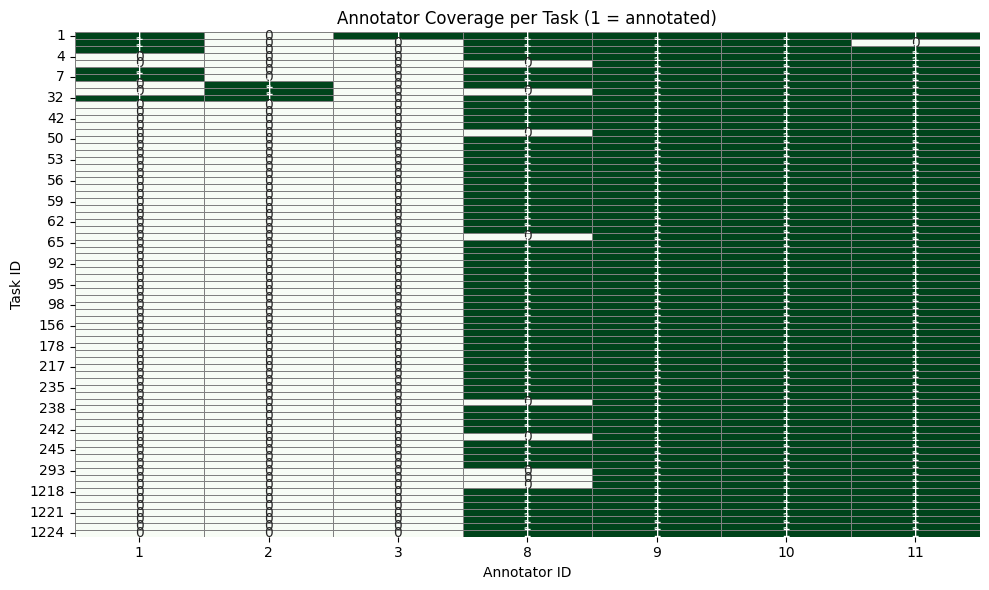

In [66]:
# display(coverage_matrix.head())
plot_annotation_coverage(coverage_matrix)

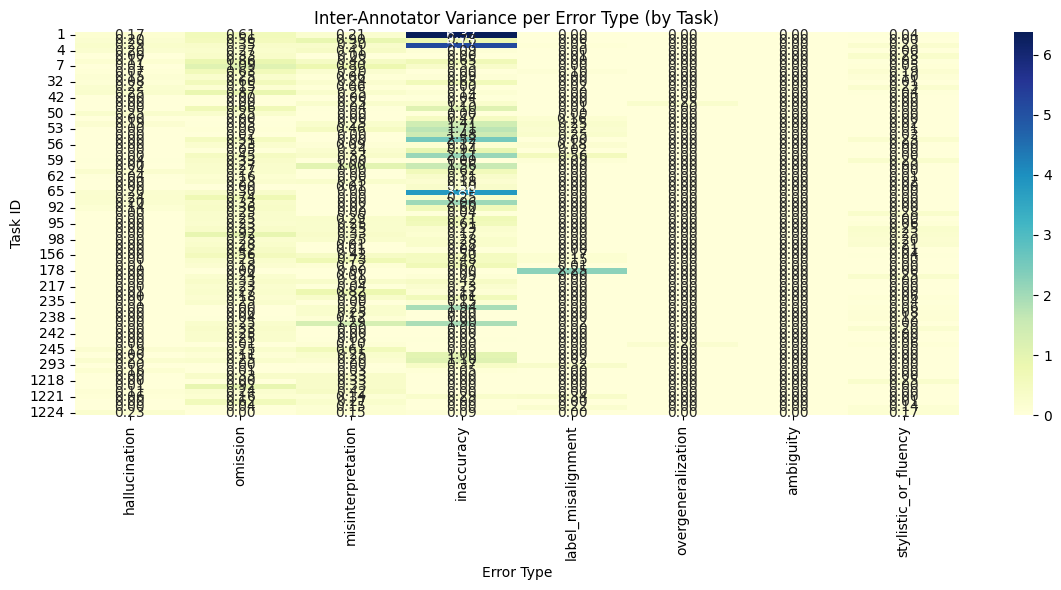

In [67]:
# Visualizations
plot_inter_annotator_variance_heatmap(inter_annotator_var)

In [127]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_inter_annotator_variance_heatmap(var_df, top_n=30, agg="sum", annot=False):
    """
    Plot a heatmap for the top-N tasks with the highest overall variance.
    """
    # Select variance columns
    var_cols = [c for c in var_df.columns if c.endswith("_var")]
    if not var_cols:
        raise ValueError("No columns ending with '_var' were found.")

    # Build matrix indexed by task_id, coerce to numeric
    heatmap_data = var_df[["task_id"] + var_cols].copy()
    for c in var_cols:
        heatmap_data[c] = pd.to_numeric(heatmap_data[c], errors="coerce")
    heatmap_data = heatmap_data.set_index("task_id")

    # Score each task by overall variance and take top-N
    if agg not in {"sum", "mean", "max"}:
        raise ValueError("agg must be one of {'sum','mean','max'}")
    scores = getattr(heatmap_data, agg)(axis=1)
    top_order = scores.sort_values(ascending=False).index[:min(top_n, len(scores))]
    heatmap_top = heatmap_data.loc[top_order]

    # Pretty column names
    heatmap_top.columns = [c.replace("_var", "") for c in heatmap_top.columns]

    # Plot
    plt.figure(figsize=(12, max(6, 0.3 * len(heatmap_top))))
    sns.heatmap(heatmap_top, cmap="YlGnBu", annot=annot, fmt=".2f", cbar=True)
    plt.title(f"Inter-Annotator Variance per Error Type — Top {len(heatmap_top)} Tasks by {agg.title()} Variance")
    plt.xlabel("Error Type")
    plt.ylabel("Task ID")
    plt.tight_layout()
    plt.show()


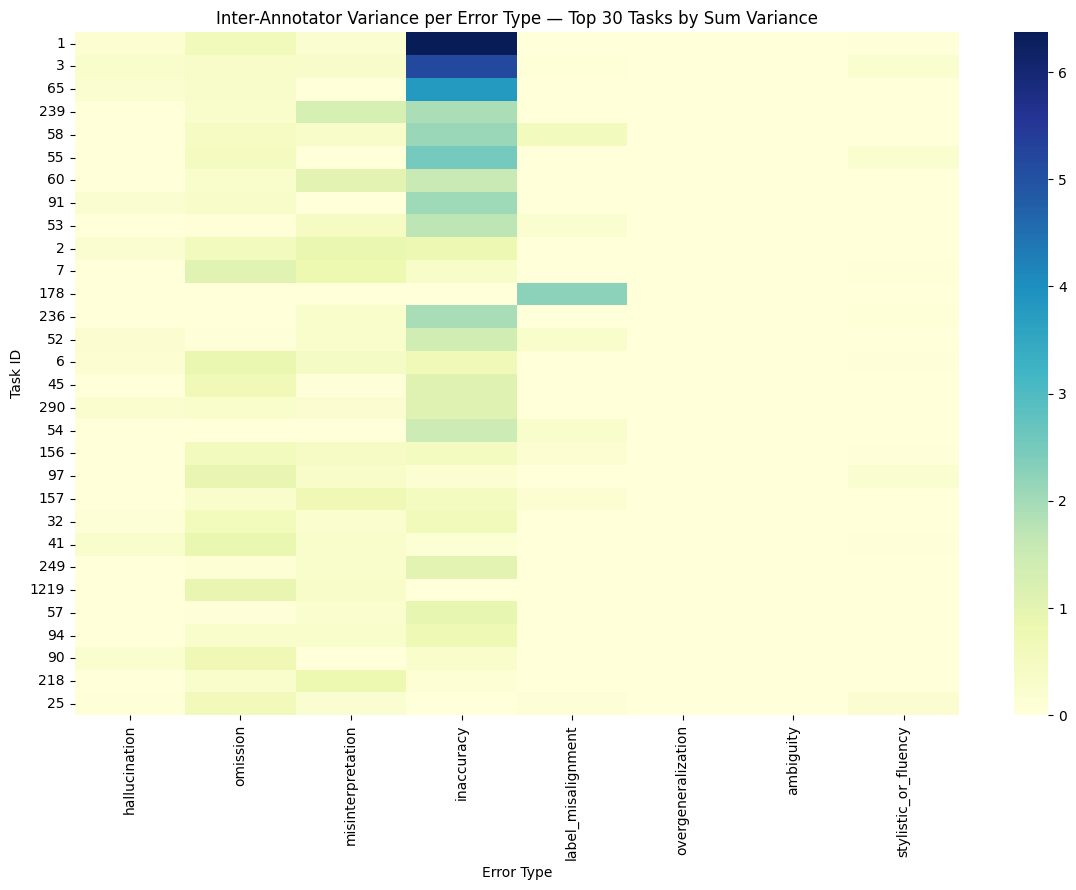

In [128]:
# By total variance across error types (recommended)
plot_inter_annotator_variance_heatmap(inter_annotator_var, top_n=30, agg="sum", annot=False)

# If you prefer to rank by the maximum variance among error types:
# plot_inter_annotator_variance_heatmap(var_df, top_n=30, agg="max")


#### Annalyze Results

In [ ]:
# task_variances = display_inter_annotator_stats(stats_df)

# Running Dataset-scale Error Analysis

#### Perform Bulk Error Analysis

In [70]:
from pathlib import Path
from tqdm import tqdm

# === Load input file ===
# input_path = Path("reformatted_label_data.json")
input_path = Path(f"{REFORMATTED_DATASET_OUTPUT_DIR}/{MERGED_DATASET_FILENAME}")
with input_path.open("r", encoding="utf-8") as f:
    label_data = json.load(f)

# === Perform analysis ===
for task in tqdm(label_data, desc="Processing tasks"):
    model_caption = task.get("gpt_annotation", "").strip()
    for annotation in task.get("annotations", []):
        human_caption = annotation.get("annotation", "").strip()
        if model_caption and human_caption:
            try:
                analysis_result = get_error_analysis_response(model_caption, human_caption)
                # annotation["auto_error_analysis"] = analysis_result
                annotation.update(analysis_result)
            except:     # Skip when error 
                continue

# === Save to output file ===
output_path = Path(f"{'dataset-wide_analysis'}/{'reformatted_label_data_with_analysis.json'}")
with output_path.open("w", encoding="utf-8") as f:
    json.dump(label_data, f, indent=2, ensure_ascii=False)

print(f"✅ Saved output to: {output_path}")

Processing tasks: 100%|██████████| 806/806 [3:02:35<00:00, 13.59s/it]  


✅ Saved output to: dataset-wide_analysis\reformatted_label_data_with_analysis.json


# Dataset-scale Error Analysis

In [97]:
# === Modular Analysis Code for Error Counts and Severity ===

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

# Set global display precision to 3 decimal places
pd.set_option('display.precision', 3)

# === Load Annotated Data ===
def load_annotation_data(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)

# === Compute Total and Average Error Counts ===
def compute_error_type_summary(data, error_types):
    error_counts = []
    for task in data:
        for annotation in task.get("annotations", []):
            # counts = annotation.get("auto_error_analysis", {}).get("error_analysis", {}).get("counts", {})
            counts = annotation.get("error_analysis", {}).get("counts", {})
            entry = {etype: counts.get(etype, 0) for etype in error_types}
            error_counts.append(entry)
    df_errors = pd.DataFrame(error_counts)
    summary_df = pd.DataFrame({
        "Total": df_errors.sum(),
        "Average": df_errors.mean()
    })
    return df_errors, summary_df

# === Plot Error Count Distributions ===
def plot_error_distributions(df_errors, error_types):
    for etype in error_types:
        distribution = df_errors[etype].value_counts().sort_index()
        plt.figure(figsize=(6, 4))
        sns.barplot(x=distribution.index, y=distribution.values)
        plt.title(f"Distribution of '{etype}' Counts")
        plt.xlabel("Count")
        plt.ylabel("Number of Annotations")
        plt.tight_layout()
        plt.show()

# === Compute Error Severity Breakdown ===
# def compute_severity_breakdown(data):
#     severity_counts = defaultdict(Counter)
#     for task in data:
#         for annotation in task.get("annotations", []):
#             details = annotation.get("auto_error_analysis", {}).get("error_analysis", {}).get("details", {})
#             for error_type, error_list in details.items():
#                 for error in error_list:
#                     severity = error.get("error_severity", "unspecified")
#                     severity_counts[error_type][severity] += 1
#     severity_df = pd.DataFrame(severity_counts).fillna(0).astype(int).T
#     return severity_df

def compute_severity_breakdown(data, plot_type=None):
    """
    Computes the breakdown of error severity levels per error category.

    Args:
        data (list): The loaded dataset from the JSON file.
        plot_type (str, optional): Filter by figure type. Default is None.

    Returns:
        pd.DataFrame: A table of error types vs severity counts.
    """
    severity_counts = defaultdict(Counter)

    for task in data:
        for annotation in task.get("annotations", []):
             # ✅ Apply figure type filtering if specified
            # print(f"Figure Type >> {task.get('figure_type')}")
            if plot_type and annotation.get("figure_type") != plot_type:
                continue

            # details = annotation.get("auto_error_analysis", {}).get("error_analysis", {}).get("details", {})
            details = annotation.get("error_analysis", {}).get("details", {})
            for error_type, error_list in details.items():
                for error in error_list:
                    severity = error.get("error_severity", "unspecified")
                    severity_counts[error_type][severity] += 1

    severity_df = pd.DataFrame(severity_counts).fillna(0).astype(int).T
    return severity_df

# === Format Severity Table with Percentages ===
def format_severity_table_with_percentages(severity_df):
    severity_df = severity_df[["minor", "moderate", "critical"]] if set(["minor", "moderate", "critical"]).issubset(severity_df.columns) else severity_df
    # formatted_df = severity_df.copy()
    formatted_df = severity_df.copy().astype("object")
    row_totals = severity_df.sum(axis=1)
    for error_type in severity_df.index:
        total = row_totals[error_type]
        for severity in severity_df.columns:
            count = severity_df.loc[error_type, severity]
            percentage = (count / total * 100) if total > 0 else 0
            formatted_df.loc[error_type, severity] = f"{count} ({percentage:.0f}%)"
    return formatted_df

# === Constants ===
ERROR_TYPES = [
    "hallucination", "omission", "misinterpretation", "inaccuracy",
    "label_misalignment", "overgeneralization", "ambiguity", "stylistic_or_fluency"
]
SEVERITY_LEVELS = ["minor", "moderate", "critical"]


In [82]:
# Load the data
# data = load_annotation_data("reformatted_label_data_with_analysis.json")
data = load_annotation_data(f"{'dataset-wide_analysis'}/{'reformatted_label_data_with_analysis.json'}")

In [83]:
# Compute and display error type summary
full_dataset_df_errors, full_dataset_summary_df = compute_error_type_summary(data, ERROR_TYPES)
display(full_dataset_summary_df)

,Total,Average
hallucination,277,0.229
omission,1066,0.880
misinterpretation,939,0.775
inaccuracy,2490,2.054
label_misalignment,242,0.200
overgeneralization,18,0.015
ambiguity,0,0.000
stylistic_or_fluency,190,0.157


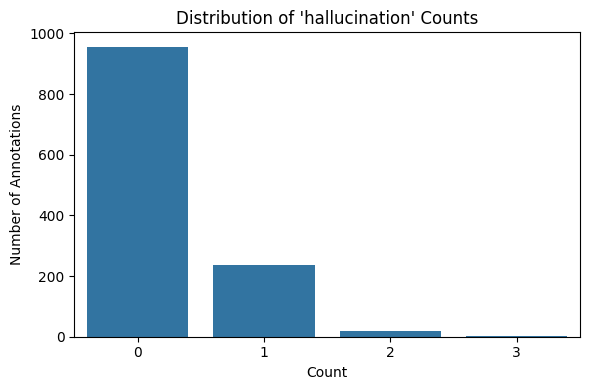

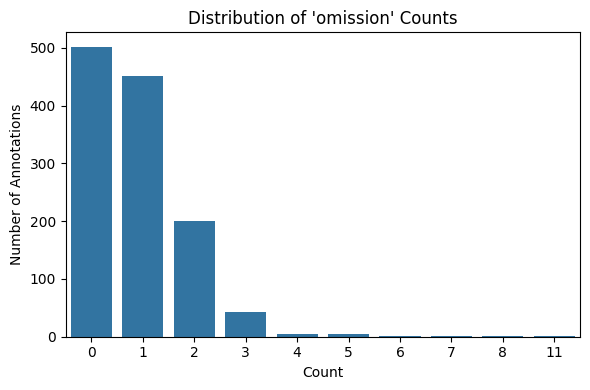

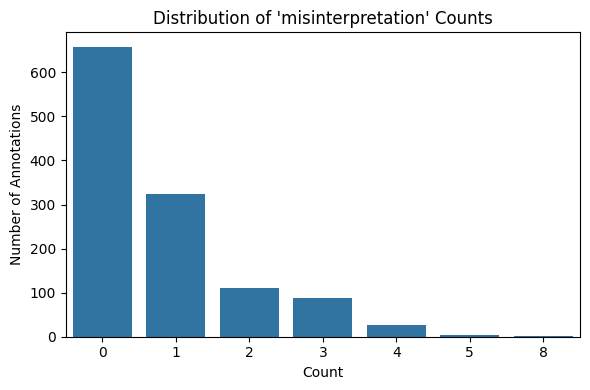

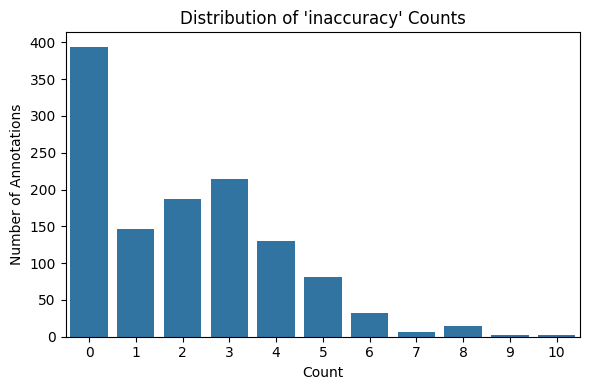

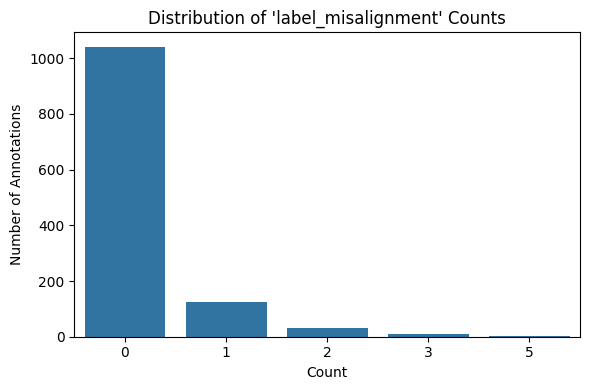

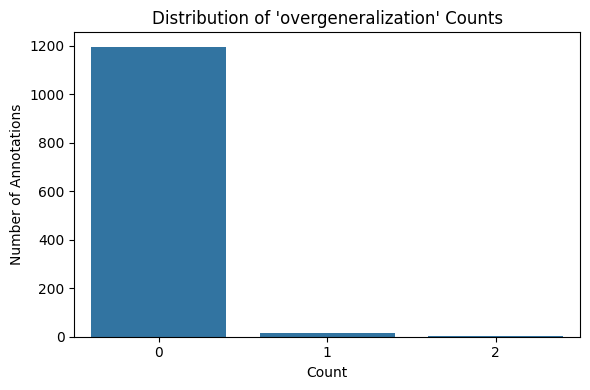

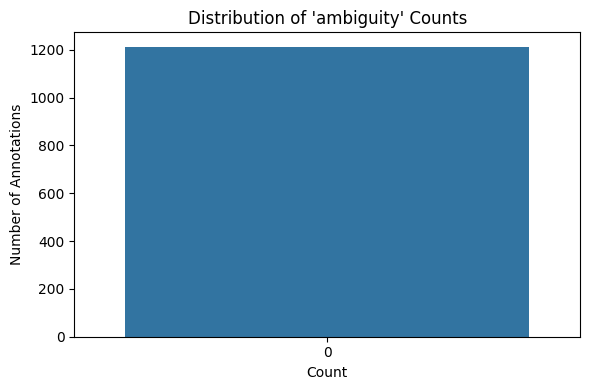

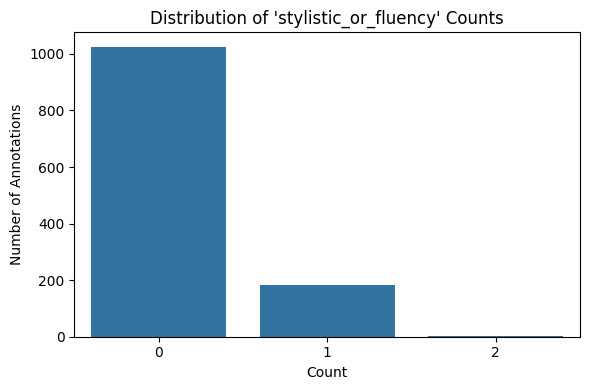

In [95]:
# Plot error count distributions
plot_error_distributions(full_dataset_df_errors, ERROR_TYPES)

In [86]:
# Compute and display severity breakdown with percentages
full_dataset_severity_df = compute_severity_breakdown(data)
full_dataset_formatted_severity_df = format_severity_table_with_percentages(full_dataset_severity_df)
display(full_dataset_formatted_severity_df)

""


#### Compute Breakdown for specific plot types

In [98]:
print("\nLine Plot Error Analysis\n")

line_plot_severity_df = compute_severity_breakdown(data, plot_type="Line Plot")
line_plot_formatted_severity_df = format_severity_table_with_percentages(line_plot_severity_df)
display(line_plot_formatted_severity_df)


Line Plot Error Analysis



,minor,moderate,critical
misinterpretation,30 (5%),291 (45%),319 (50%)
inaccuracy,552 (33%),882 (52%),249 (15%)
stylistic_or_fluency,92 (100%),0 (0%),0 (0%)
omission,170 (33%),339 (65%),10 (2%)
hallucination,28 (27%),56 (54%),19 (18%)
label_misalignment,70 (45%),41 (26%),46 (29%)
overgeneralization,3 (43%),4 (57%),0 (0%)


In [99]:
print("\nBar Chart Error Analysis\n")

bar_chart_severity_df = compute_severity_breakdown(data, plot_type="Bar Chart")
bar_chart_formatted_severity_df = format_severity_table_with_percentages(bar_chart_severity_df)
display(bar_chart_formatted_severity_df)


Bar Chart Error Analysis



,minor,moderate,critical
hallucination,34 (31%),52 (48%),22 (20%)
omission,76 (18%),350 (81%),5 (1%)
misinterpretation,21 (12%),102 (58%),54 (31%)
inaccuracy,211 (32%),332 (50%),124 (19%)
stylistic_or_fluency,81 (100%),0 (0%),0 (0%)
overgeneralization,4 (44%),5 (56%),0 (0%)
label_misalignment,20 (45%),14 (32%),10 (23%)


In [100]:
print("\nPie Chart Error Analysis\n")

pie_chart_severity_df = compute_severity_breakdown(data, plot_type="Pie Chart")
pie_chart_formatted_severity_df = format_severity_table_with_percentages(pie_chart_severity_df)
display(pie_chart_formatted_severity_df)


Pie Chart Error Analysis



,minor,moderate,critical
hallucination,6 (10%),31 (50%),25 (40%)
omission,12 (13%),75 (79%),8 (8%)
misinterpretation,22 (19%),69 (61%),22 (19%)
inaccuracy,35 (34%),48 (47%),19 (19%)
label_misalignment,14 (38%),18 (49%),5 (14%)
stylistic_or_fluency,19 (100%),0 (0%),0 (0%)
overgeneralization,0 (0%),2 (100%),0 (0%)
